# CO2 Awareness Experiment - Data Analysis

This notebook analyzes data from participants in the CO2 awareness experiment.

**Key Research Questions:**
1. Did participants improve their CO2 knowledge after the learning intervention?
2. Does the effect differ by demographics (age, gender, diet)?
3. What do participants report learning from the experience?

**Data Structure:**
- 6 quiz scores: `normal_products` (pre/post), `ah_products` (pre/post), and `personal_products` (pre/post)
- Demographics (age, gender, diet, shopping frequency)
- Likert questionnaires (pre & post attitudes)
- Open-ended reflection responses

## 1. Import Required Libraries

In [36]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import json
from datetime import datetime, timezone
from dotenv import load_dotenv
from supabase import create_client

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 2. Load Data from Supabase

This notebook loads directly from Supabase using credentials in `../.env`.
No local API server (`npm run dev`) is required for analysis.

In [37]:
# Configuration
COMPLETED_ONLY = True  # Set to False to include incomplete sessions


def fetch_data_from_supabase(completed_only=True):
    """Fetch experiment data directly from Supabase (no local server required)."""
    # Load env from project root (../.env when notebook is in analysis/)
    load_dotenv(Path.cwd().parent / '.env')

    supabase_url = os.getenv('SUPABASE_URL')
    supabase_key = os.getenv('SUPABASE_SERVICE_ROLE_KEY') or os.getenv('SUPABASE_ANON_KEY')

    if not supabase_url or not supabase_key:
        raise ValueError("Missing SUPABASE_URL and SUPABASE_SERVICE_ROLE_KEY/SUPABASE_ANON_KEY in .env")

    sb = create_client(supabase_url, supabase_key)
    query = sb.table('experiment_sessions').select('*').order('started_at', desc=False)

    if completed_only:
        query = query.eq('current_step', 'complete')

    resp = query.execute()
    sessions = resp.data or []

    return {
        'exportedAt': datetime.now(timezone.utc).isoformat(),
        'count': len(sessions),
        'completedCount': sum(1 for s in sessions if s.get('current_step') == 'complete'),
        'sessions': sessions,
        'source': 'supabase_direct'
    }


# Load data
raw_data = fetch_data_from_supabase(COMPLETED_ONLY)

if raw_data:
    print("✅ Loaded data directly from Supabase")
    print(f"✅ Loaded {raw_data['count']} sessions ({raw_data.get('completedCount', 'N/A')} completed)")
    print(f"   Exported at: {raw_data['exportedAt']}")
    print(f"   Source: {raw_data.get('source', 'supabase_direct')}")

✅ Loaded data directly from Supabase
✅ Loaded 105 sessions (105 completed)
   Exported at: 2026-06-02T18:55:40.511888+00:00
   Source: supabase_direct


In [3]:
# Convert to DataFrame
sessions = raw_data.get('sessions', [])

def flatten_session(s):
    demographics = s.get('demographics') or {}
    pre_q = s.get('pre_questionnaire') or {}
    post_q = s.get('post_questionnaire_closed') or {}

    normal_products_pre_score = (s.get('quiz1_data') or {}).get('score')
    personal_products_pre_score = (s.get('quiz2_data') or {}).get('score')
    normal_products_post_score = (s.get('quiz3_data') or {}).get('score')
    personal_products_post_score = (s.get('quiz4_data') or {}).get('score')
    ah_products_pre_score = (s.get('quiz5_data') or {}).get('score')
    ah_products_post_score = (s.get('quiz6_data') or {}).get('score')

    return {
        'id': s.get('id'),
        'bonus_card': s.get('bonus_card'),
        'anonymous_id': s.get('anonymous_id'),
        'ab_variant': s.get('ab_variant'),
        'current_step': s.get('current_step'),
        'consent_given': s.get('consent_given'),
        'started_at': s.get('started_at'),
        'completed_at': s.get('completed_at'),
        'updated_at': s.get('updated_at'),

        # Demographics
        'demo_age': demographics.get('demo_age'),
        'demo_gender': demographics.get('demo_gender'),
        'demo_education': demographics.get('demo_education'),
        'demo_diet': demographics.get('demo_diet'),
        'demo_shopping_frequency': demographics.get('demo_shopping_frequency'),

        # Quiz scores (renamed)
        'normal_products_pre_score': normal_products_pre_score,
        'normal_products_post_score': normal_products_post_score,
        'ah_products_pre_score': ah_products_pre_score,
        'ah_products_post_score': ah_products_post_score,
        'personal_products_pre_score': personal_products_pre_score,
        'personal_products_post_score': personal_products_post_score,

        # Improvement metrics (renamed)
        'normal_products_improvement': (normal_products_post_score - normal_products_pre_score)
            if normal_products_pre_score is not None and normal_products_post_score is not None else None,
        'ah_products_improvement': (ah_products_post_score - ah_products_pre_score)
            if ah_products_pre_score is not None and ah_products_post_score is not None else None,
        'personal_products_improvement': (personal_products_post_score - personal_products_pre_score)
            if personal_products_pre_score is not None and personal_products_post_score is not None else None,

        # Pre-questionnaire
        'pre_q1': pre_q.get('pre_q1'),
        'pre_q2': pre_q.get('pre_q2'),
        'pre_q3': pre_q.get('pre_q3'),
        'pre_q4': pre_q.get('pre_q4'),
        'pre_q5': pre_q.get('pre_q5'),
        'pre_q6': pre_q.get('pre_q6'),

        # Post-questionnaire
        'post_q1': post_q.get('post_q1'),
        'post_q2': post_q.get('post_q2'),
        'post_q3': post_q.get('post_q3'),
        'post_q4': post_q.get('post_q4'),
        'post_q5': post_q.get('post_q5'),
        'post_q6': post_q.get('post_q6'),
        'post_q7': post_q.get('post_q7'),
    }

flat_data = [flatten_session(s) for s in sessions]
df = pd.DataFrame(flat_data)

# Convert timestamps
for col in ['started_at', 'completed_at', 'updated_at']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

print(f"DataFrame shape: {df.shape}")
print(f"Columns available: {len(df.columns)}")
df.head()

DataFrame shape: (63, 36)
Columns available: 36


,id,bonus_card,anonymous_id,ab_variant,current_step,consent_given,started_at,completed_at,updated_at,demo_age,demo_gender,demo_education,demo_diet,demo_shopping_frequency,normal_products_pre_score,normal_products_post_score,ah_products_pre_score,ah_products_post_score,personal_products_pre_score,personal_products_post_score,normal_products_improvement,ah_products_improvement,personal_products_improvement,pre_q1,pre_q2,pre_q3,pre_q4,pre_q5,pre_q6,post_q1,post_q2,post_q3,post_q4,post_q5,post_q6,post_q7
0,bbb08a68-8e6c-4c77-9d1e-cfc919c79a24,2621669441317,anon-821526eb-c763-4a52-9094-a12884572e8f,A,complete,True,2026-04-16 15:45:45.005665+00:00,2026-04-16 15:59:45.222000+00:00,2026-04-16 15:59:45.222000+00:00,21,man,None,omnivore,2_3_per_week,67,56,22,56,67,56,-11,34,-11,2,4,3,5,4,3,4,4,5,5,5,4,5
1,eec44ee2-1b77-4092-9389-edda175a59d8,2620679788559,anon-76830190-c174-4fdd-8472-c33053d6222f,A,complete,True,2026-04-16 16:03:32.866218+00:00,2026-04-16 16:15:57.416000+00:00,2026-04-16 16:15:57.416000+00:00,23,woman,None,vegetarian,weekly,78,56,56,78,67,56,-22,22,-11,4,4,3,5,4,4,5,5,4,5,5,5,5
2,e2299ec3-fd9b-4ffc-b5ab-37d1f7132358,2620677373658,anon-2ff84736-510b-48c3-be31-a242b12d5eb2,A,complete,True,2026-04-16 16:04:09.867803+00:00,2026-04-16 16:23:00.663000+00:00,2026-04-16 16:23:00.663000+00:00,21,woman,None,omnivore,weekly,89,56,44,78,56,44,-33,34,-12,3,4,4,2,1,3,4,5,4,5,5,5,5
3,d47f010d-05e3-436e-98d7-1f4b91b239c6,2620696506761,anon-fe9851d2-fd65-47e0-8fbe-b9da14703e19,B,complete,True,2026-04-17 11:20:02.663981+00:00,2026-04-17 11:36:40.244000+00:00,2026-04-17 11:36:40.244000+00:00,23,man,None,omnivore,2_3_per_week,67,89,67,67,67,100,22,0,33,3,2,4,4,2,2,4,5,5,4,4,3,4
4,3b4aacff-b057-4e0f-b499-d7ca5f178ed4,2621621505101,anon-f625c037-8697-4f5d-83e0-cbd173fc1e07,A,complete,True,2026-04-17 11:25:22.123299+00:00,2026-04-17 11:49:59.328000+00:00,2026-04-17 11:49:59.330000+00:00,27,prefer_not_to_say,None,vegetarian,2_3_per_week,56,44,44,67,33,11,-12,23,-22,3,4,1,1,2,4,4,5,3,4,5,4,3


## 3. Data Inspection

Understand the structure and quality of the data.

In [28]:
# Basic info about the dataset
print("=== Dataset Info ===")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn types:")
df.info()

=== Dataset Info ===
Shape: 63 rows × 36 columns

Column types:
<class 'pandas.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 36 columns):
 #   Column                         Non-Null Count  Dtype              
---  ------                         --------------  -----              
 0   id                             63 non-null     str                
 1   bonus_card                     63 non-null     str                
 2   anonymous_id                   63 non-null     str                
 3   ab_variant                     63 non-null     str                
 4   current_step                   63 non-null     str                
 5   consent_given                  63 non-null     bool               
 6   started_at                     63 non-null     datetime64[us, UTC]
 7   completed_at                   63 non-null     datetime64[us, UTC]
 8   updated_at                     63 non-null     datetime64[us, UTC]
 9   demo_age                       63 non-null     

In [29]:
# Check key columns for missing values
key_columns = [
    'normal_products_pre_score', 'normal_products_post_score',
    'ah_products_pre_score', 'ah_products_post_score',
    'personal_products_pre_score', 'personal_products_post_score',
    'demo_age', 'demo_gender', 'demo_diet'
]

print("=== Missing Values in Key Columns ===")
missing = df[key_columns].isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values in key columns!")

print("\n=== Quiz Score Ranges ===")
score_cols = [c for c in df.columns if c.endswith('_score') and ('products' in c)]
df[score_cols].describe().round(1)

=== Missing Values in Key Columns ===
No missing values in key columns!

=== Quiz Score Ranges ===


,normal_products_pre_score,normal_products_post_score,ah_products_pre_score,ah_products_post_score,personal_products_pre_score,personal_products_post_score
count,63.0,63.0,63.0,63.0,63.0,63.0
mean,42.6,64.0,43.6,63.6,49.1,61.0
std,30.5,21.4,24.2,21.9,22.4,23.3
min,0.0,11.0,0.0,0.0,0.0,0.0
25%,11.0,56.0,22.0,56.0,33.0,44.0
50%,56.0,67.0,44.0,67.0,56.0,67.0
75%,67.0,78.0,56.0,78.0,67.0,78.0
max,89.0,100.0,89.0,100.0,89.0,100.0


## 4. Demographics Overview

Understand who participated in the experiment.

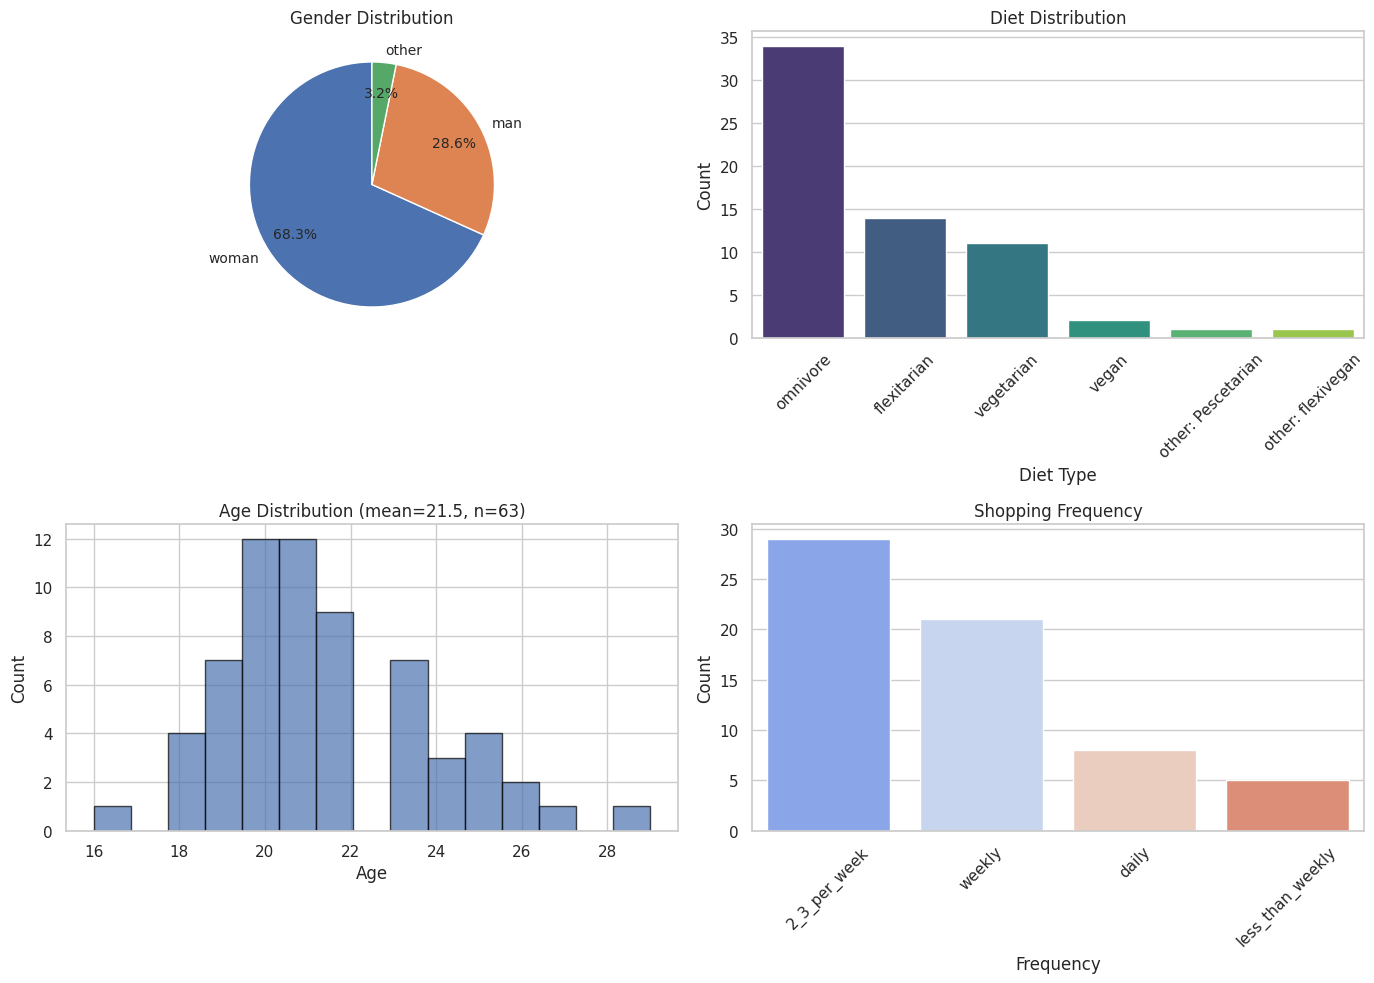


=== Demographics Summary ===

demo_gender:
demo_gender
woman                43
man                  18
prefer_not_to_say     1
non_binary            1
Name: count, dtype: int64

demo_diet:
demo_diet
omnivore              34
flexitarian           14
vegetarian            11
vegan                  2
other: Pescetarian     1
other: flexivegan      1
Name: count, dtype: int64

demo_shopping_frequency:
demo_shopping_frequency
2_3_per_week        29
weekly              21
daily                8
less_than_weekly     5
Name: count, dtype: int64


In [30]:
# Demographics breakdown
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gender distribution (group very small categories for readability)
if 'demo_gender' in df.columns:
    gender_counts = df['demo_gender'].value_counts()
    gender_plot = gender_counts.copy()
    small_mask = (gender_plot / gender_plot.sum()) < 0.03
    if small_mask.any():
        other_sum = gender_plot[small_mask].sum()
        gender_plot = gender_plot[~small_mask]
        if other_sum > 0:
            gender_plot['other'] = other_sum

    axes[0, 0].pie(
        gender_plot,
        labels=gender_plot.index,
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.75,
        textprops={'fontsize': 10}
    )
    axes[0, 0].set_title('Gender Distribution')

# Diet distribution
if 'demo_diet' in df.columns:
    diet_counts = df['demo_diet'].value_counts().reset_index()
    diet_counts.columns = ['diet', 'count']
    sns.barplot(
        data=diet_counts,
        x='diet',
        y='count',
        hue='diet',
        legend=False,
        ax=axes[0, 1],
        palette='viridis'
    )
    axes[0, 1].set_title('Diet Distribution')
    axes[0, 1].set_xlabel('Diet Type')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].tick_params(axis='x', rotation=45)

# Age distribution
if 'demo_age' in df.columns:
    df['demo_age_numeric'] = pd.to_numeric(df['demo_age'], errors='coerce')
    ages = df['demo_age_numeric'].dropna()
    axes[1, 0].hist(ages, bins=15, edgecolor='black', alpha=0.7)
    axes[1, 0].set_title(f'Age Distribution (mean={ages.mean():.1f}, n={len(ages)})')
    axes[1, 0].set_xlabel('Age')
    axes[1, 0].set_ylabel('Count')

# Shopping frequency
if 'demo_shopping_frequency' in df.columns:
    freq_counts = df['demo_shopping_frequency'].value_counts().reset_index()
    freq_counts.columns = ['frequency', 'count']
    sns.barplot(
        data=freq_counts,
        x='frequency',
        y='count',
        hue='frequency',
        legend=False,
        ax=axes[1, 1],
        palette='coolwarm'
    )
    axes[1, 1].set_title('Shopping Frequency')
    axes[1, 1].set_xlabel('Frequency')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Summary table
print("\n=== Demographics Summary ===")
for col in ['demo_gender', 'demo_diet', 'demo_shopping_frequency']:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts())

## 5. Learning Effect Analysis (Pre vs Post)

**Key hypothesis:** Participants score higher on post-intervention quizzes than pre-intervention quizzes.

Quiz pairs:
- **normal_products:** pre → post
- **ah_products:** pre → post
- **personal_products:** pre → post

We use **paired t-tests** since each participant has both pre and post scores.

In [31]:
def analyze_learning_effect(df, pre_col, post_col, label):
    """Perform paired t-test and calculate effect size for pre/post comparison."""
    paired = df[[pre_col, post_col]].dropna()

    if len(paired) < 3:
        return {'label': label, 'error': f'Insufficient data (n={len(paired)})'}

    pre = paired[pre_col]
    post = paired[post_col]

    t_stat, p_value = stats.ttest_rel(post, pre)

    try:
        w_stat, w_pvalue = stats.wilcoxon(post - pre)
    except:
        w_stat, w_pvalue = None, None

    diff = post - pre
    cohens_d = diff.mean() / diff.std() if diff.std() > 0 else 0

    return {
        'label': label,
        'n': len(paired),
        'pre_mean': pre.mean(),
        'pre_std': pre.std(),
        'post_mean': post.mean(),
        'post_std': post.std(),
        'improvement': post.mean() - pre.mean(),
        't_statistic': t_stat,
        'p_value': p_value,
        'wilcoxon_p': w_pvalue,
        'cohens_d': cohens_d,
        'significant': p_value < 0.05
    }

quiz_pairs = [
    ('normal_products_pre_score', 'normal_products_post_score', 'normal_products'),
    ('ah_products_pre_score', 'ah_products_post_score', 'ah_products'),
    ('personal_products_pre_score', 'personal_products_post_score', 'personal_products'),
]

results = []
for pre, post, label in quiz_pairs:
    result = analyze_learning_effect(df, pre, post, label)
    results.append(result)

results_df = pd.DataFrame(results)
print("=" * 80)
print("LEARNING EFFECT ANALYSIS - PAIRED T-TEST RESULTS")
print("=" * 80)

for r in results:
    if 'error' in r:
        print(f"\n{r['label']}: {r['error']}")
        continue

    sig_marker = "***" if r['p_value'] < 0.001 else "**" if r['p_value'] < 0.01 else "*" if r['p_value'] < 0.05 else "ns"
    effect_size = "large" if abs(r['cohens_d']) >= 0.8 else "medium" if abs(r['cohens_d']) >= 0.5 else "small" if abs(r['cohens_d']) >= 0.2 else "negligible"

    print(f"\n{'─' * 60}")
    print(f"📊 {r['label']} (n={r['n']})")
    print(f"{'─' * 60}")
    print(f"   Pre-test:     {r['pre_mean']:.1f} ± {r['pre_std']:.1f}")
    print(f"   Post-test:    {r['post_mean']:.1f} ± {r['post_std']:.1f}")
    print(f"   Improvement:  {r['improvement']:+.1f} points")
    print(f"")
    print(f"   t-statistic:  {r['t_statistic']:.3f}")
    print(f"   p-value:      {r['p_value']:.4f} {sig_marker}")
    print(f"   Cohen's d:    {r['cohens_d']:.3f} ({effect_size} effect)")

print(f"\n{'=' * 80}")
print("Significance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")

LEARNING EFFECT ANALYSIS - PAIRED T-TEST RESULTS

────────────────────────────────────────────────────────────
📊 normal_products (n=63)
────────────────────────────────────────────────────────────
   Pre-test:     42.6 ± 30.5
   Post-test:    64.0 ± 21.4
   Improvement:  +21.4 points

   t-statistic:  4.940
   p-value:      0.0000 ***
   Cohen's d:    0.622 (medium effect)

────────────────────────────────────────────────────────────
📊 ah_products (n=63)
────────────────────────────────────────────────────────────
   Pre-test:     43.6 ± 24.2
   Post-test:    63.6 ± 21.9
   Improvement:  +20.0 points

   t-statistic:  5.784
   p-value:      0.0000 ***
   Cohen's d:    0.729 (medium effect)

────────────────────────────────────────────────────────────
📊 personal_products (n=63)
────────────────────────────────────────────────────────────
   Pre-test:     49.1 ± 22.4
   Post-test:    61.0 ± 23.3
   Improvement:  +11.9 points

   t-statistic:  3.352
   p-value:      0.0014 **
   Cohen's d

## 6. Data Visualization

Visual comparison of pre vs post quiz scores.

/tmp/ipykernel_49231/1597565676.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([pre_data, post_data], labels=['Pre', 'Post'], patch_artist=True)
/tmp/ipykernel_49231/1597565676.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([pre_data, post_data], labels=['Pre', 'Post'], patch_artist=True)
/tmp/ipykernel_49231/1597565676.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([pre_data, post_data], labels=['Pre', 'Post'], patch_artist=True)


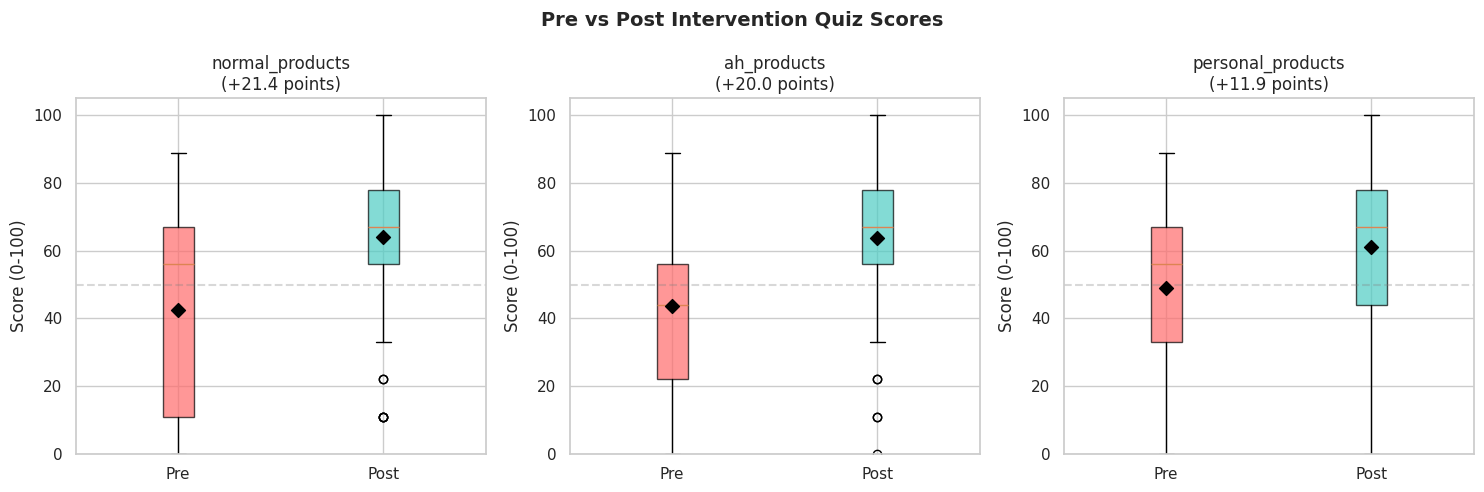

In [32]:
# Box plots comparing pre vs post scores
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

quiz_pairs = [
    ('normal_products_pre_score', 'normal_products_post_score', 'normal_products'),
    ('ah_products_pre_score', 'ah_products_post_score', 'ah_products'),
    ('personal_products_pre_score', 'personal_products_post_score', 'personal_products'),
]

colors = ['#ff6b6b', '#4ecdc4']

for ax, (pre, post, title) in zip(axes, quiz_pairs):
    pre_data = df[pre].dropna()
    post_data = df[post].dropna()

    bp = ax.boxplot([pre_data, post_data], labels=['Pre', 'Post'], patch_artist=True)

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.scatter([1, 2], [pre_data.mean(), post_data.mean()], color='black', marker='D', s=50, zorder=3, label='Mean')

    improvement = post_data.mean() - pre_data.mean()
    ax.set_title(f'{title}\n(+{improvement:.1f} points)', fontsize=12)
    ax.set_ylabel('Score (0-100)')
    ax.set_ylim(0, 105)
    ax.axhline(y=50, color='gray', linestyle='--', alpha=0.3, label='Random (50)')

plt.suptitle('Pre vs Post Intervention Quiz Scores', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

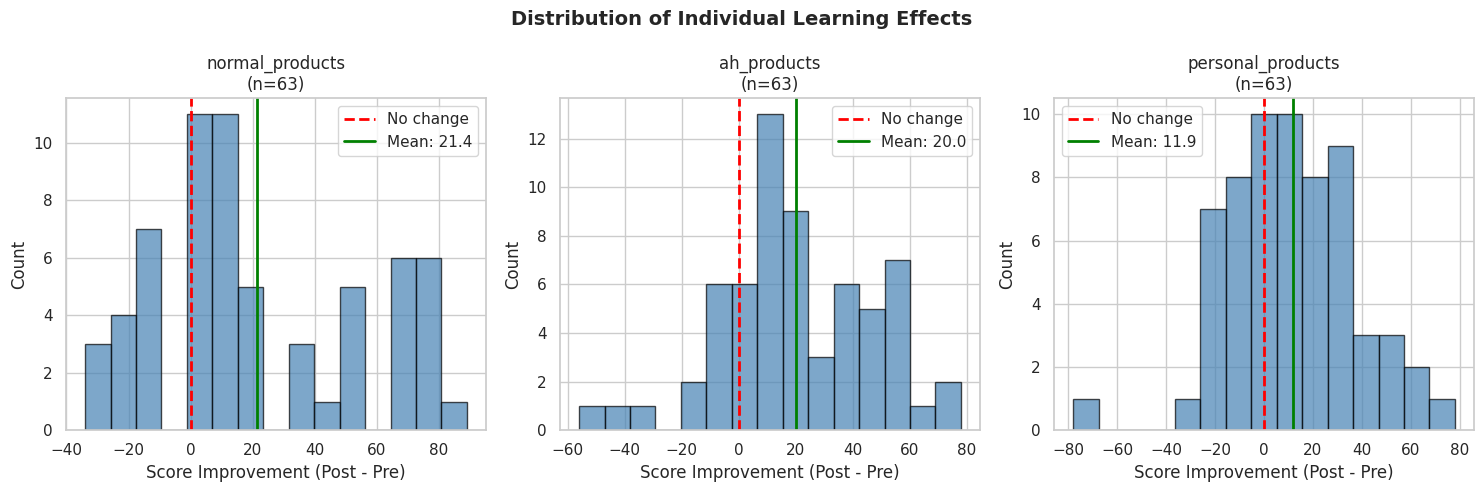


=== Percentage of Participants Who Improved ===
normal_products: 60.3% improved, 17.5% same, 22.2% worse
ah_products: 73.0% improved, 9.5% same, 17.5% worse
personal_products: 57.1% improved, 15.9% same, 27.0% worse


In [33]:
# Individual improvement distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

improvement_cols = [
    ('normal_products_improvement', 'normal_products'),
    ('ah_products_improvement', 'ah_products'),
    ('personal_products_improvement', 'personal_products'),
]

for ax, (col, title) in zip(axes, improvement_cols):
    if col in df.columns:
        data = df[col].dropna()

        ax.hist(data, bins=15, edgecolor='black', alpha=0.7, color='steelblue')
        ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No change')
        ax.axvline(x=data.mean(), color='green', linestyle='-', linewidth=2, label=f'Mean: {data.mean():.1f}')

        ax.set_title(f'{title}\n(n={len(data)})')
        ax.set_xlabel('Score Improvement (Post - Pre)')
        ax.set_ylabel('Count')
        ax.legend()

plt.suptitle('Distribution of Individual Learning Effects', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Percentage of Participants Who Improved ===")
for col, label in improvement_cols:
    if col in df.columns:
        data = df[col].dropna()
        pct_improved = (data > 0).mean() * 100
        pct_same = (data == 0).mean() * 100
        pct_worse = (data < 0).mean() * 100
        print(f"{label}: {pct_improved:.1f}% improved, {pct_same:.1f}% same, {pct_worse:.1f}% worse")

## 7. Learning Effect by Demographics

Does the intervention work better for certain groups?

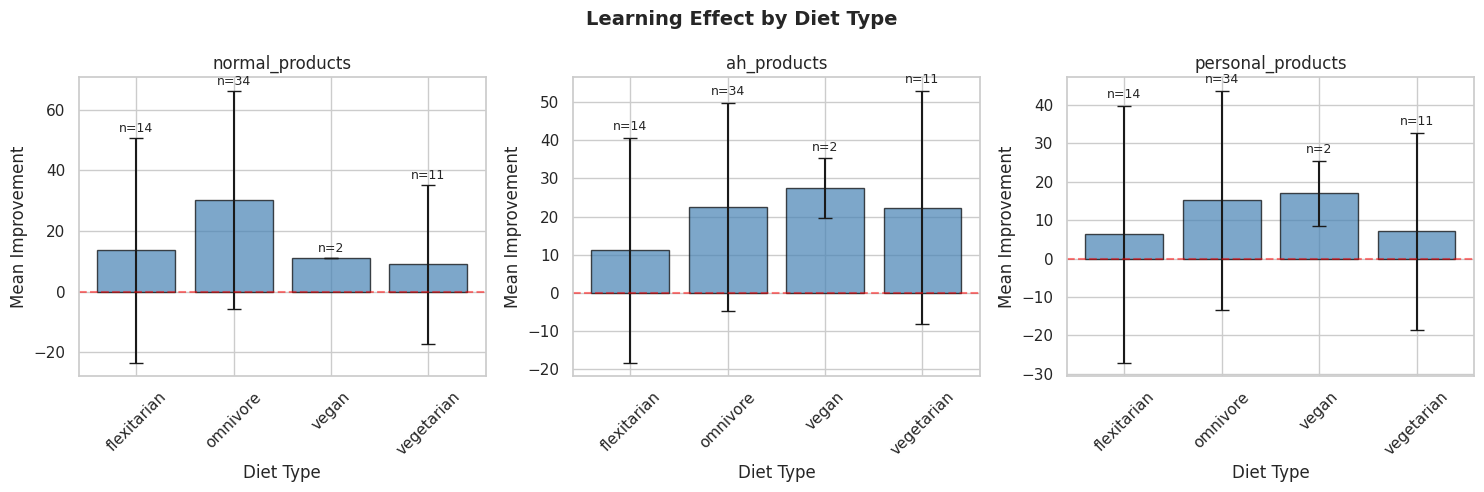

In [34]:
# Learning effect by diet type
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

improvement_cols = ['normal_products_improvement', 'ah_products_improvement', 'personal_products_improvement']
titles = ['normal_products', 'ah_products', 'personal_products']

for ax, col, title in zip(axes, improvement_cols, titles):
    if col in df.columns and 'demo_diet' in df.columns:
        diet_data = df.groupby('demo_diet')[col].agg(['mean', 'std', 'count']).reset_index()
        diet_data = diet_data[diet_data['count'] >= 2]

        if len(diet_data) > 0:
            ax.bar(
                diet_data['demo_diet'],
                diet_data['mean'],
                yerr=diet_data['std'],
                capsize=5,
                color='steelblue',
                alpha=0.7,
                edgecolor='black'
            )

            for i, (_, row) in enumerate(diet_data.iterrows()):
                ax.text(i, row['mean'] + row['std'] + 2, f"n={int(row['count'])}", ha='center', fontsize=9)

            ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
            ax.set_title(title)
            ax.set_xlabel('Diet Type')
            ax.set_ylabel('Mean Improvement')
            ax.tick_params(axis='x', rotation=45)

plt.suptitle('Learning Effect by Diet Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Questionnaire Analysis

Analyze attitudes and self-perceptions before and after the intervention.

**Pre-questionnaire (1-5 Likert):**
- pre_q1: I consider my food choices environmentally sustainable
- pre_q2: I feel confident in my knowledge of food environmental impact
- pre_q3: I trust eco-labels when buying food
- pre_q4: Eco-labels are easy to understand
- pre_q5: I find it easy to compare products by environmental impact
- pre_q6: I actively consider environmental impact when buying food

**Post-questionnaire (1-5 Likert):**
- post_q1: Better understanding of environmental impact after study
- post_q2: The ranking system was clear and easy to understand
- post_q3: I trust the CO₂ ranking system presented
- post_q4: This system is clearer than existing eco-labels
- post_q5: Feedback on personal purchases was useful
- post_q6: Would use this information for future choices
- post_q7: Quizzes helped me learn about environmental impact

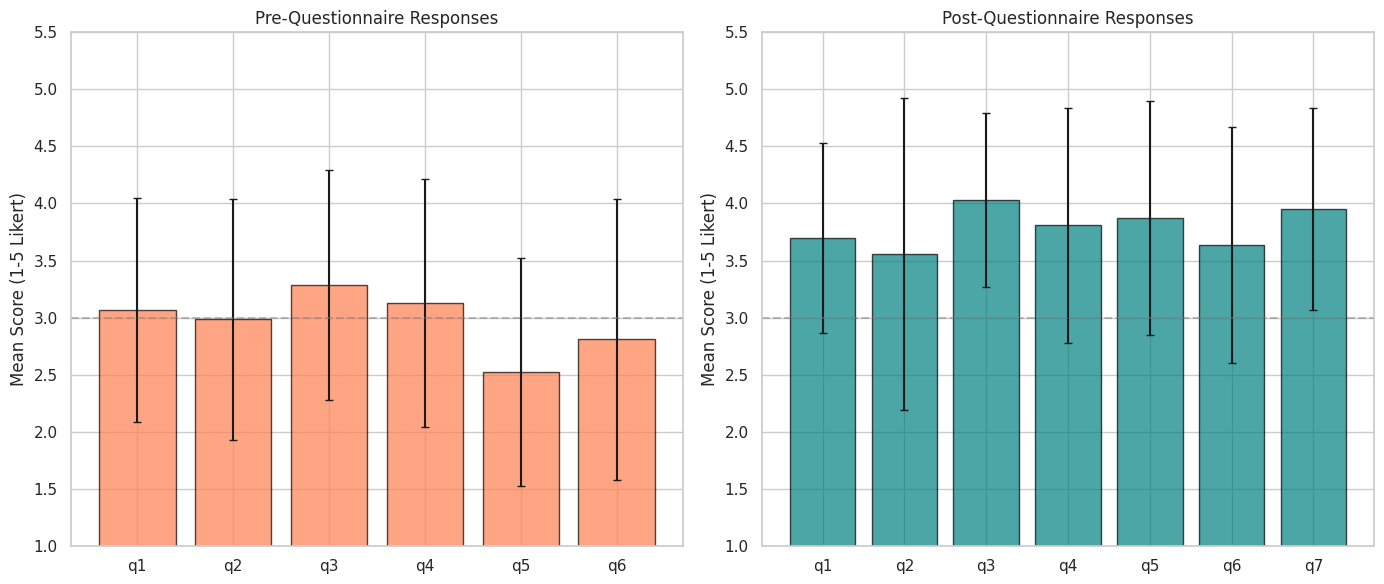

=== Questionnaire Summary Statistics ===

Pre-Questionnaire:
        mean   std  min  max
pre_q1  3.06  0.98  1.0  5.0
pre_q2  2.98  1.05  1.0  5.0
pre_q3  3.29  1.01  1.0  5.0
pre_q4  3.13  1.08  1.0  5.0
pre_q5  2.52  1.00  1.0  5.0
pre_q6  2.81  1.23  1.0  5.0

Post-Questionnaire:
         mean   std  min  max
post_q1  3.70  0.84  1.0  5.0
post_q2  3.56  1.37  1.0  5.0
post_q3  4.03  0.76  2.0  5.0
post_q4  3.81  1.03  1.0  5.0
post_q5  3.87  1.02  1.0  5.0
post_q6  3.63  1.04  1.0  5.0
post_q7  3.95  0.89  1.0  5.0


In [35]:
# Questionnaire response analysis
pre_q_cols = [c for c in df.columns if c.startswith('pre_q') and c[5:].isdigit()]
post_q_cols = [c for c in df.columns if c.startswith('post_q') and c[6:].isdigit()]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pre-questionnaire
if pre_q_cols:
    pre_means = df[pre_q_cols].mean()
    pre_stds = df[pre_q_cols].std()
    
    x = range(len(pre_q_cols))
    axes[0].bar(x, pre_means, yerr=pre_stds, capsize=3, color='coral', alpha=0.7, edgecolor='black')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([c.replace('pre_', '') for c in pre_q_cols])
    axes[0].set_ylabel('Mean Score (1-5 Likert)')
    axes[0].set_title('Pre-Questionnaire Responses')
    axes[0].set_ylim(1, 5.5)
    axes[0].axhline(y=3, color='gray', linestyle='--', alpha=0.5, label='Neutral (3)')

# Post-questionnaire
if post_q_cols:
    post_means = df[post_q_cols].mean()
    post_stds = df[post_q_cols].std()
    
    x = range(len(post_q_cols))
    axes[1].bar(x, post_means, yerr=post_stds, capsize=3, color='teal', alpha=0.7, edgecolor='black')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([c.replace('post_', '') for c in post_q_cols])
    axes[1].set_ylabel('Mean Score (1-5 Likert)')
    axes[1].set_title('Post-Questionnaire Responses')
    axes[1].set_ylim(1, 5.5)
    axes[1].axhline(y=3, color='gray', linestyle='--', alpha=0.5, label='Neutral (3)')

plt.tight_layout()
plt.show()

# Summary statistics
print("=== Questionnaire Summary Statistics ===")
print("\nPre-Questionnaire:")
print(df[pre_q_cols].describe().round(2).T[['mean', 'std', 'min', 'max']])
print("\nPost-Questionnaire:")
print(df[post_q_cols].describe().round(2).T[['mean', 'std', 'min', 'max']])

## 9. Qualitative Responses

Open-ended reflection responses for thematic analysis.

In [36]:
# Extract qualitative responses from raw data
qualitative_responses = []

for session in sessions:
    reflection = session.get('_post_questionnaire_open') or session.get('_reflection') or {}
    if reflection and isinstance(reflection, dict):
        entry = {
            'session_id': session.get('id', '')[:8],
            'diet': session.get('demographics', {}).get('demo_diet') if isinstance(session.get('demographics'), dict) else None,
            'normal_products_improvement': (
                ((session.get('quiz3_data') or {}).get('score') - (session.get('quiz1_data') or {}).get('score'))
                if (session.get('quiz1_data') or {}).get('score') is not None and (session.get('quiz3_data') or {}).get('score') is not None
                else None
            ),
        }
        for key, value in reflection.items():
            if isinstance(value, str) and value.strip():
                entry[key] = value.strip()

        if len(entry) > 3:
            qualitative_responses.append(entry)

print(f"Found {len(qualitative_responses)} responses with open-ended feedback\n")

question_keys = ['ref_reflection', 'ref_surprise', 'ref_system_feedback', 'ref_trust_comparison', 'ref_improvement']

for key in question_keys:
    responses_for_key = [(r['session_id'], r.get(key)) for r in qualitative_responses if r.get(key)]
    if responses_for_key:
        print(f"{'=' * 70}")
        print(f"📝 {key.replace('ref_', '').replace('_', ' ').upper()}")
        print(f"   ({len(responses_for_key)} responses)")
        print(f"{'=' * 70}")
        for session_id, response in responses_for_key[:5]:
            print(f"\n[{session_id}]: {response[:300]}{'...' if len(response) > 300 else ''}")
        if len(responses_for_key) > 5:
            print(f"\n... and {len(responses_for_key) - 5} more responses")
        print()

Found 0 responses with open-ended feedback



## 10. Export Data

Save processed data for further analysis (SPSS, Excel, etc.)

In [37]:
# Export options
OUTPUT_DIR = "analysis_output"
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. Save flat DataFrame to CSV (for SPSS/Excel)
csv_path = f"{OUTPUT_DIR}/experiment_data.csv"
df.to_csv(csv_path, index=False)
print(f"✅ Saved: {csv_path}")

# 2. Save qualitative responses to JSON
qual_path = f"{OUTPUT_DIR}/qualitative_responses.json"
with open(qual_path, 'w', encoding='utf-8') as f:
    json.dump(qualitative_responses, f, indent=2, ensure_ascii=False)
print(f"✅ Saved: {qual_path}")

# 3. Save statistical results
stats_df = pd.DataFrame(results)
stats_path = f"{OUTPUT_DIR}/statistical_results.csv"
stats_df.to_csv(stats_path, index=False)
print(f"✅ Saved: {stats_path}")

# 4. Save full raw data (with nested quiz details)
full_path = f"{OUTPUT_DIR}/experiment_data_full.json"
with open(full_path, 'w', encoding='utf-8') as f:
    json.dump(raw_data, f, indent=2, default=str)
print(f"✅ Saved: {full_path}")

print(f"\n📁 All files saved to: {os.path.abspath(OUTPUT_DIR)}")

✅ Saved: analysis_output/experiment_data.csv
✅ Saved: analysis_output/qualitative_responses.json
✅ Saved: analysis_output/statistical_results.csv
✅ Saved: analysis_output/experiment_data_full.json

📁 All files saved to: /home/montague/Downloads/AH2/sustainable-shop-webapp/analysis/analysis_output


## Summary

Key findings from this analysis:

1. **Learning Effect**: Check the paired t-test results above to see if scores improved significantly
2. **Effect Size**: Cohen's d indicates the practical significance of the improvement
3. **Demographics**: Review if certain groups benefit more from the intervention
4. **User Feedback**: Qualitative responses provide insight into user experience

---
*Generated by experiment_analysis.ipynb*

## Reversed-Order Detection\n\nSome participants misread the task and sorted **LOWEST → HIGHEST** instead of **HIGHEST → LOWEST**.\nThis cell detects sessions where a user's ranking is strongly inversely correlated with the correct order (i.e. they reversed it).\n\nFor each quiz the stored `correctOrder` array gives the ground truth positions. We compute the Spearman rank correlation between the user's submitted order and the correct order:\n- **≈ +1.0** → user got it right\n- **≈ −1.0** → user fully reversed the order\n- near 0 → random / unsure\n\nSessions with correlation < −0.7 on any quiz are flagged.

In [48]:
import math
import os
from pathlib import Path
from pprint import pprint

from dotenv import load_dotenv
from supabase import create_client

load_dotenv(Path.cwd().parent / '.env')
SUPABASE_URL = os.getenv('SUPABASE_URL')
SUPABASE_KEY = os.getenv('SUPABASE_SERVICE_ROLE_KEY')

if not SUPABASE_URL or not SUPABASE_KEY:
    raise ValueError('Missing SUPABASE_URL or SUPABASE_SERVICE_ROLE_KEY in environment')

sb = create_client(SUPABASE_URL, SUPABASE_KEY)

QUIZ_KEYS = ['quiz1_data', 'quiz2_data', 'quiz3_data', 'quiz4_data', 'quiz5_data', 'quiz6_data']
QUIZ_LABEL = {
    'quiz1_data': 'normal_products_pre',
    'quiz3_data': 'normal_products_post',
    'quiz5_data': 'ah_products_pre',
    'quiz6_data': 'ah_products_post',
    'quiz2_data': 'personal_products_pre',
    'quiz4_data': 'personal_products_post',
}
REVERSAL_THRESHOLD = -0.7

def rankdata(values):
    sorted_pairs = sorted(enumerate(values), key=lambda x: x[1])
    ranks = [0.0] * len(values)
    i = 0
    while i < len(sorted_pairs):
        j = i
        while j + 1 < len(sorted_pairs) and sorted_pairs[j + 1][1] == sorted_pairs[i][1]:
            j += 1
        avg_rank = (i + j) / 2 + 1
        for k in range(i, j + 1):
            ranks[sorted_pairs[k][0]] = avg_rank
        i = j + 1
    return ranks

def pearsonr(x, y):
    n = len(x)
    if n < 2:
        return None
    mean_x = sum(x) / n
    mean_y = sum(y) / n
    num = sum((a - mean_x) * (b - mean_y) for a, b in zip(x, y))
    den_x = math.sqrt(sum((a - mean_x) ** 2 for a in x))
    den_y = math.sqrt(sum((b - mean_y) ** 2 for b in y))
    if den_x == 0 or den_y == 0:
        return None
    return num / (den_x * den_y)

def spearmanr_simple(x, y):
    if len(x) != len(y) or len(x) < 2:
        return None
    return pearsonr(rankdata(x), rankdata(y))

def spearman_vs_correct(quiz_data):
    if not quiz_data:
        return None
    user_ranking = quiz_data.get('user_ranking') or []
    correct_order = quiz_data.get('correctOrder') or []
    if len(user_ranking) < 3 or len(correct_order) < 3:
        return None
    correct_pos = {item['id']: i for i, item in enumerate(correct_order)}
    user_pos = {item['id']: i for i, item in enumerate(user_ranking)}
    common_ids = [k for k in correct_pos if k in user_pos]
    if len(common_ids) < 3:
        return None
    c = [correct_pos[k] for k in common_ids]
    u = [user_pos[k] for k in common_ids]
    r = spearmanr_simple(c, u)
    return None if r is None else round(r, 3)

resp = sb.table('experiment_sessions').select('id, bonus_card, current_step, demographics, ' + ', '.join(QUIZ_KEYS)).execute()
sessions = resp.data
print(f'Fetched {len(sessions)} sessions')

reversed_sessions = []
for s in sessions:
    result = {
        'session_id': s['id'],
        'bonus_card': s.get('bonus_card', '—'),
        'current_step': s.get('current_step'),
        'quiz_correlations': {},
        'reversed_in': []
    }
    for key in QUIZ_KEYS:
        r = spearman_vs_correct(s.get(key))
        result['quiz_correlations'][QUIZ_LABEL[key]] = r
        if r is not None and r < REVERSAL_THRESHOLD:
            result['reversed_in'].append(QUIZ_LABEL[key])
    if result['reversed_in']:
        reversed_sessions.append(result)

print(f'\n{len(reversed_sessions)} sessions with suspected reversed rankings:\n')
pprint(reversed_sessions[:20])

reversed_sessions

Fetched 63 sessions

22 sessions with suspected reversed rankings:

[{'bonus_card': 'CART_986a0521e05b',
  'current_step': 'complete',
  'quiz_correlations': {'ah_products_post': 0.314,
                        'ah_products_pre': -0.657,
                        'normal_products_post': 0.943,
                        'normal_products_pre': -0.943,
                        'personal_products_post': 0.943,
                        'personal_products_pre': -0.829},
  'reversed_in': ['normal_products_pre', 'personal_products_pre'],
  'session_id': '986a0521-e05b-4afd-ab17-77ab9a5a87b4'},
 {'bonus_card': 'CART_5458bf54714b',
  'current_step': 'complete',
  'quiz_correlations': {'ah_products_post': 0.714,
                        'ah_products_pre': 0.486,
                        'normal_products_post': -0.029,
                        'normal_products_pre': -0.771,
                        'personal_products_post': 0.943,
                        'personal_products_pre': 0.2},
  'reversed_in': ['norm

[{'session_id': '986a0521-e05b-4afd-ab17-77ab9a5a87b4',
  'bonus_card': 'CART_986a0521e05b',
  'current_step': 'complete',
  'quiz_correlations': {'normal_products_pre': -0.943,
   'personal_products_pre': -0.829,
   'normal_products_post': 0.943,
   'personal_products_post': 0.943,
   'ah_products_pre': -0.657,
   'ah_products_post': 0.314},
  'reversed_in': ['normal_products_pre', 'personal_products_pre']},
 {'session_id': '5458bf54-714b-4102-a0ad-6d8cc48a7290',
  'bonus_card': 'CART_5458bf54714b',
  'current_step': 'complete',
  'quiz_correlations': {'normal_products_pre': -0.771,
   'personal_products_pre': 0.2,
   'normal_products_post': -0.029,
   'personal_products_post': 0.943,
   'ah_products_pre': 0.486,
   'ah_products_post': 0.714},
  'reversed_in': ['normal_products_pre']},
 {'session_id': '9d8f705f-bffe-42a3-8668-0309b584f7f6',
  'bonus_card': 'CART_9d8f705fbffe',
  'current_step': 'complete',
  'quiz_correlations': {'normal_products_pre': -1.0,
   'personal_products_pre'

In [49]:
## ── Fix reversed rankings ────────────────────────────────────────────────────
# Set DRY_RUN = True to preview what would change without writing to the DB.
# Set DRY_RUN = False to actually apply the corrections.
DRY_RUN = True

# Optionally restrict to specific session IDs (leave empty to fix ALL flagged sessions)
FIX_ONLY_SESSIONS = []  # e.g. ['abc-123', 'def-456']

def distance_score(user_order, correct_order):
    """Recompute score: sum of |position differences|, normalised to 0-100."""
    correct_pos = {item['id']: i for i, item in enumerate(correct_order)}
    n = len(correct_order)
    total_dist = sum(abs(correct_pos.get(item['id'], i) - i) for i, item in enumerate(user_order))
    # Max possible distance for n items reversed
    max_dist = sum(abs(i - (n - 1 - i)) for i in range(n))
    if max_dist == 0:
        return 100
    return round((1 - total_dist / max_dist) * 100)

# Use detected reversed sessions from previous cell
to_fix = [row['session_id'] for row in reversed_sessions]
if FIX_ONLY_SESSIONS:
    to_fix = [sid for sid in to_fix if sid in FIX_ONLY_SESSIONS]

print(f"{'[DRY RUN] ' if DRY_RUN else ''}Fixing {len(to_fix)} session(s)...\n")

for sid in to_fix:
    session = next((s for s in sessions if s['id'] == sid), None)
    if not session:
        continue

    updates = {}
    for key in QUIZ_KEYS:
        qd = session.get(key)
        if not qd:
            continue

        r = spearman_vs_correct(qd)
        if r is None or r >= REVERSAL_THRESHOLD:
            continue  # Not reversed — skip

        user_ranking = qd.get('user_ranking', [])
        correct_order = qd.get('correctOrder', [])

        # Reverse the submitted ranking
        fixed_ranking = list(reversed(user_ranking))
        new_score = distance_score(fixed_ranking, correct_order)

        updates[key] = {
            **qd,
            'user_ranking': fixed_ranking,
            'score': new_score,
            'reversed_correction': True,
        }
        print(f"  {sid[:8]}… {QUIZ_LABEL[key]}: score {qd.get('score')} → {new_score}  (r={r})")

    if updates and not DRY_RUN:
        sb.table('experiment_sessions').update(updates).eq('id', sid).execute()
        print("  ✓ Written to DB")
    elif updates and DRY_RUN:
        print(f"  [DRY RUN] Would update {len(updates)} quiz(zes) for session {sid[:8]}…")

print("\nDone. Set DRY_RUN = False to apply changes.")

[DRY RUN] Fixing 22 session(s)...

  986a0521… normal_products_pre: score 0 → 89  (r=-0.943)
  986a0521… personal_products_pre: score 11 → 78  (r=-0.829)
  [DRY RUN] Would update 2 quiz(zes) for session 986a0521…
  5458bf54… normal_products_pre: score 0 → 67  (r=-0.771)
  [DRY RUN] Would update 1 quiz(zes) for session 5458bf54…
  9d8f705f… normal_products_pre: score 0 → 100  (r=-1.0)
  9d8f705f… personal_products_pre: score 0 → 67  (r=-0.771)
  9d8f705f… personal_products_post: score 0 → 67  (r=-0.771)
  [DRY RUN] Would update 3 quiz(zes) for session 9d8f705f…
  bb3a59a5… normal_products_pre: score 11 → 67  (r=-0.771)
  [DRY RUN] Would update 1 quiz(zes) for session bb3a59a5…
  c26dbd3b… ah_products_pre: score 0 → 78  (r=-0.886)
  [DRY RUN] Would update 1 quiz(zes) for session c26dbd3b…
  660d38e0… normal_products_post: score 11 → 78  (r=-0.886)
  660d38e0… personal_products_post: score 0 → 89  (r=-0.943)
  660d38e0… ah_products_post: score 0 → 78  (r=-0.886)
  [DRY RUN] Would update 3

## Focused accidental-misread detection\n\nThis section narrows the broader reversed-ranking detection into likely **instruction misreads**:\n\n- **Q1 misreaders**: reversed on the very first sorting task, but not generally reversed later\n- **First-three misreaders**: reversed on at least 2 of the first 3 sorting tasks, but mostly corrected themselves in the post-intervention quizzes\n\nExperiment order is: **Q1 → Q2 AH (= quiz5) → Q3 personal (= quiz2) → Q4 → Q5 → Q6**.

In [40]:
PRE_ORDER = ['quiz1_data', 'quiz5_data', 'quiz2_data']
POST_ORDER = ['quiz3_data', 'quiz6_data', 'quiz4_data']

POSITIVE_THRESHOLD = 0.3
NEGATIVE_THRESHOLD = REVERSAL_THRESHOLD

def quiz_corr_map(session):
    return {key: spearman_vs_correct(session.get(key)) for key in QUIZ_KEYS}

def is_reversed(r):
    return r is not None and r < NEGATIVE_THRESHOLD

def is_positive(r):
    return r is not None and r > POSITIVE_THRESHOLD

def summarize_session(session):
    corrs = quiz_corr_map(session)
    pre_reversed = [QUIZ_LABEL[k] for k in PRE_ORDER if is_reversed(corrs[k])]
    post_positive = [QUIZ_LABEL[k] for k in POST_ORDER if is_positive(corrs[k])]
    post_reversed = [QUIZ_LABEL[k] for k in POST_ORDER if is_reversed(corrs[k])]
    return {
        'session_id': session['id'],
        'bonus_card': session.get('bonus_card', '—'),
        'current_step': session.get('current_step'),
        'pre_reversed': pre_reversed,
        'post_positive': post_positive,
        'post_reversed': post_reversed,
        'corrs': {QUIZ_LABEL[k]: corrs[k] for k in QUIZ_KEYS},
    }

q1_misreaders = []
for s in sessions:
    summary = summarize_session(s)
    q1_r = summary['corrs']['normal_products_pre']
    if is_reversed(q1_r) and len(summary['post_positive']) >= 2 and len(summary['post_reversed']) <= 1:
        q1_misreaders.append(summary)

first_three_misreaders = []
for s in sessions:
    summary = summarize_session(s)
    if len(summary['pre_reversed']) >= 2 and len(summary['post_positive']) >= 2:
        first_three_misreaders.append(summary)

print('Likely normal_products_pre misreaders (later behavior mostly corrected):')
for row in q1_misreaders:
    print(f"- {row['session_id']} | bonus_card={row['bonus_card']} | post_positive={row['post_positive']}")
print(f"Total: {len(q1_misreaders)}\n")

print('Likely first-three misreaders (>=2 reversed in first 3, >=2 positive in last 3):')
for row in first_three_misreaders:
    print(f"- {row['session_id']} | bonus_card={row['bonus_card']} | pre_reversed={row['pre_reversed']} | post_positive={row['post_positive']}")
print(f"Total: {len(first_three_misreaders)}\n")

focused_misread_output = {
    'q1_misreaders': q1_misreaders,
    'first_three_misreaders': first_three_misreaders,
}
focused_misread_output

Likely normal_products_pre misreaders (later behavior mostly corrected):
- 986a0521-e05b-4afd-ab17-77ab9a5a87b4 | bonus_card=CART_986a0521e05b | post_positive=['normal_products_post', 'ah_products_post', 'personal_products_post']
- 5458bf54-714b-4102-a0ad-6d8cc48a7290 | bonus_card=CART_5458bf54714b | post_positive=['ah_products_post', 'personal_products_post']
- bb3a59a5-5a7d-4813-8333-3b098a8e437a | bonus_card=CART_bb3a59a55a7d | post_positive=['normal_products_post', 'ah_products_post']
- 2484e621-9f6f-47c6-bf9c-9e8df42c3601 | bonus_card=CART_2484e6219f6f | post_positive=['normal_products_post', 'ah_products_post', 'personal_products_post']
- 68661d30-550b-4e2f-bda2-ab3de5d155f0 | bonus_card=2622185336743 | post_positive=['normal_products_post', 'ah_products_post', 'personal_products_post']
- dca22322-ed10-4ea1-b384-16280e1988a9 | bonus_card=CART_dca22322ed10 | post_positive=['normal_products_post', 'ah_products_post', 'personal_products_post']
- d309068f-051c-498a-b081-2b0a31c3bc07 

{'q1_misreaders': [{'session_id': '986a0521-e05b-4afd-ab17-77ab9a5a87b4',
   'bonus_card': 'CART_986a0521e05b',
   'current_step': 'complete',
   'pre_reversed': ['normal_products_pre', 'personal_products_pre'],
   'post_positive': ['normal_products_post',
    'ah_products_post',
    'personal_products_post'],
   'post_reversed': [],
   'corrs': {'normal_products_pre': -0.943,
    'personal_products_pre': -0.829,
    'normal_products_post': 0.943,
    'personal_products_post': 0.943,
    'ah_products_pre': -0.657,
    'ah_products_post': 0.314}},
  {'session_id': '5458bf54-714b-4102-a0ad-6d8cc48a7290',
   'bonus_card': 'CART_5458bf54714b',
   'current_step': 'complete',
   'pre_reversed': ['normal_products_pre'],
   'post_positive': ['ah_products_post', 'personal_products_post'],
   'post_reversed': [],
   'corrs': {'normal_products_pre': -0.771,
    'personal_products_pre': 0.2,
    'normal_products_post': -0.029,
    'personal_products_post': 0.943,
    'ah_products_pre': 0.486,
    

In [41]:
# Which likely normal_products_pre misreaders put beef first?

BEEF_NAMES = {'ground beef', 'rundergehakt'}

q1_beef_first = []
for row in q1_misreaders:
    session = next((s for s in sessions if s['id'] == row['session_id']), None)
    if not session:
        continue
    quiz1 = session.get('quiz1_data') or {}
    user_ranking = quiz1.get('user_ranking') or []
    if not user_ranking:
        continue
    first_item = user_ranking[0]
    first_name = (first_item.get('name') or '').strip().lower()
    if first_name in BEEF_NAMES:
        q1_beef_first.append({
            'session_id': row['session_id'],
            'bonus_card': row['bonus_card'],
            'first_item': first_item.get('name'),
            'q1_corr': row['corrs']['normal_products_pre'],
            'pre_reversed': row['pre_reversed'],
            'post_positive': row['post_positive'],
        })

print('Likely normal_products_pre misreaders who put beef first:')
for item in q1_beef_first:
    print(f"- {item['session_id']} | bonus_card={item['bonus_card']} | first_item={item['first_item']} | q1_corr={item['q1_corr']}")
print(f"Total: {len(q1_beef_first)}")

q1_beef_first

Likely normal_products_pre misreaders who put beef first:
- 986a0521-e05b-4afd-ab17-77ab9a5a87b4 | bonus_card=CART_986a0521e05b | first_item=Ground Beef | q1_corr=-0.943
- bb3a59a5-5a7d-4813-8333-3b098a8e437a | bonus_card=CART_bb3a59a55a7d | first_item=Ground Beef | q1_corr=-0.771
- 2484e621-9f6f-47c6-bf9c-9e8df42c3601 | bonus_card=CART_2484e6219f6f | first_item=Ground Beef | q1_corr=-0.829
- 68661d30-550b-4e2f-bda2-ab3de5d155f0 | bonus_card=2622185336743 | first_item=Ground Beef | q1_corr=-0.771
- d309068f-051c-498a-b081-2b0a31c3bc07 | bonus_card=2620678981951 | first_item=Ground Beef | q1_corr=-0.886
- 4992851d-3a88-46a0-8e26-3e186483f2b1 | bonus_card=CART_4992851d3a88 | first_item=Ground Beef | q1_corr=-0.829
- 9ddb493d-77a4-4840-8ac4-bbeeefdc3901 | bonus_card=CART_9ddb493d77a4 | first_item=Ground Beef | q1_corr=-0.886
- 7efce358-e163-4958-ad77-3d6164074d51 | bonus_card=CART_7efce358e163 | first_item=Ground Beef | q1_corr=-0.829
- 3db6901f-8935-4252-9c8a-5e071561c928 | bonus_card=CA

[{'session_id': '986a0521-e05b-4afd-ab17-77ab9a5a87b4',
  'bonus_card': 'CART_986a0521e05b',
  'first_item': 'Ground Beef',
  'q1_corr': -0.943,
  'pre_reversed': ['normal_products_pre', 'personal_products_pre'],
  'post_positive': ['normal_products_post',
   'ah_products_post',
   'personal_products_post']},
 {'session_id': 'bb3a59a5-5a7d-4813-8333-3b098a8e437a',
  'bonus_card': 'CART_bb3a59a55a7d',
  'first_item': 'Ground Beef',
  'q1_corr': -0.771,
  'pre_reversed': ['normal_products_pre'],
  'post_positive': ['normal_products_post', 'ah_products_post']},
 {'session_id': '2484e621-9f6f-47c6-bf9c-9e8df42c3601',
  'bonus_card': 'CART_2484e6219f6f',
  'first_item': 'Ground Beef',
  'q1_corr': -0.829,
  'pre_reversed': ['normal_products_pre'],
  'post_positive': ['normal_products_post',
   'ah_products_post',
   'personal_products_post']},
 {'session_id': '68661d30-550b-4e2f-bda2-ab3de5d155f0',
  'bonus_card': '2622185336743',
  'first_item': 'Ground Beef',
  'q1_corr': -0.771,
  'pre_r

In [42]:
# Users who put a meat product first in pre-quiz general (Q1) and pre-quiz AH (Q5)

MEATISH_NAMES = {
    'ground beef', 'rundergehakt',
    'beef', 'rundvlees',
    'chicken breast', 'kipfilet',
    'lamb', 'lamsvlees',
    'pork', 'varkensvlees',
    'steak', 'biefstuk'
}

def first_item_name(session, quiz_key):
    quiz = session.get(quiz_key) or {}
    ranking = quiz.get('user_ranking') or []
    if not ranking:
        return None
    return (ranking[0].get('name') or '').strip()

def is_meat_name(name):
    return bool(name) and name.strip().lower() in MEATISH_NAMES

q1_meat_first = []
q5_meat_first = []

for session in sessions:
    q1_name = first_item_name(session, 'quiz1_data')
    q5_name = first_item_name(session, 'quiz5_data')

    if is_meat_name(q1_name):
        q1_meat_first.append({
            'session_id': session['id'],
            'bonus_card': session.get('bonus_card', '—'),
            'first_item': q1_name,
            'q1_corr': spearman_vs_correct(session.get('quiz1_data')),
        })

    if is_meat_name(q5_name):
        q5_meat_first.append({
            'session_id': session['id'],
            'bonus_card': session.get('bonus_card', '—'),
            'first_item': q5_name,
            'q5_corr': spearman_vs_correct(session.get('quiz5_data')),
        })

print('Q1 (pre-quiz general): users who put meat first')
for row in q1_meat_first:
    print(f"- {row['session_id']} | bonus_card={row['bonus_card']} | first_item={row['first_item']} | q1_corr={row['q1_corr']}")
print(f"Total: {len(q1_meat_first)}\n")

print('Q5 (pre-quiz AH): users who put meat first')
for row in q5_meat_first:
    print(f"- {row['session_id']} | bonus_card={row['bonus_card']} | first_item={row['first_item']} | q5_corr={row['q5_corr']}")
print(f"Total: {len(q5_meat_first)}\n")

if len(q5_meat_first) == 0:
    print('Note: quiz 5 contains no meat products in AH_POOL_C, so this is expected.')

{
    'q1_meat_first': q1_meat_first,
    'q5_meat_first': q5_meat_first,
}

Q1 (pre-quiz general): users who put meat first
- 1f25fd9a-a759-4d2f-a687-08b8ac1f19d5 | bonus_card=2621941614590 | first_item=Ground Beef | q1_corr=0.029
- 986a0521-e05b-4afd-ab17-77ab9a5a87b4 | bonus_card=CART_986a0521e05b | first_item=Ground Beef | q1_corr=-0.943
- 3b4aacff-b057-4e0f-b499-d7ca5f178ed4 | bonus_card=2621621505101 | first_item=Chicken Breast | q1_corr=0.486
- 03448d58-d95b-44ef-88fc-561eabd272e3 | bonus_card=CART_03448d58d95b | first_item=Ground Beef | q1_corr=-0.657
- 9d8f705f-bffe-42a3-8668-0309b584f7f6 | bonus_card=CART_9d8f705fbffe | first_item=Ground Beef | q1_corr=-1.0
- bb3a59a5-5a7d-4813-8333-3b098a8e437a | bonus_card=CART_bb3a59a55a7d | first_item=Ground Beef | q1_corr=-0.771
- c26dbd3b-35c2-4e2e-b61f-407833d573d3 | bonus_card=CART_c26dbd3b35c2 | first_item=Chicken Breast | q1_corr=0.029
- 2484e621-9f6f-47c6-bf9c-9e8df42c3601 | bonus_card=CART_2484e6219f6f | first_item=Ground Beef | q1_corr=-0.829
- 258f6c03-ddb7-4106-94a8-11a8b587595c | bonus_card=CART_258f6c

{'q1_meat_first': [{'session_id': '1f25fd9a-a759-4d2f-a687-08b8ac1f19d5',
   'bonus_card': '2621941614590',
   'first_item': 'Ground Beef',
   'q1_corr': 0.029},
  {'session_id': '986a0521-e05b-4afd-ab17-77ab9a5a87b4',
   'bonus_card': 'CART_986a0521e05b',
   'first_item': 'Ground Beef',
   'q1_corr': -0.943},
  {'session_id': '3b4aacff-b057-4e0f-b499-d7ca5f178ed4',
   'bonus_card': '2621621505101',
   'first_item': 'Chicken Breast',
   'q1_corr': 0.486},
  {'session_id': '03448d58-d95b-44ef-88fc-561eabd272e3',
   'bonus_card': 'CART_03448d58d95b',
   'first_item': 'Ground Beef',
   'q1_corr': -0.657},
  {'session_id': '9d8f705f-bffe-42a3-8668-0309b584f7f6',
   'bonus_card': 'CART_9d8f705fbffe',
   'first_item': 'Ground Beef',
   'q1_corr': -1.0},
  {'session_id': 'bb3a59a5-5a7d-4813-8333-3b098a8e437a',
   'bonus_card': 'CART_bb3a59a55a7d',
   'first_item': 'Ground Beef',
   'q1_corr': -0.771},
  {'session_id': 'c26dbd3b-35c2-4e2e-b61f-407833d573d3',
   'bonus_card': 'CART_c26dbd3b35c2

In [43]:
# Full Q1 ranking dump for all sessions that put meat first
# Useful for manual diagnosis of likely accidental reversals.

q1_meat_first_rankings = []

for row in q1_meat_first:
    session = next((s for s in sessions if s['id'] == row['session_id']), None)
    if not session:
        continue

    quiz1 = session.get('quiz1_data') or {}
    user_ranking = quiz1.get('user_ranking') or []
    correct_order = quiz1.get('correctOrder') or []

    record = {
        'session_id': row['session_id'],
        'bonus_card': row['bonus_card'],
        'q1_corr': row['q1_corr'],
        'user_ranking': [item.get('name') for item in user_ranking],
        'correct_order': [item.get('name') for item in correct_order],
    }
    q1_meat_first_rankings.append(record)

for rec in q1_meat_first_rankings:
    print('=' * 100)
    print(f"SESSION: {rec['session_id']}")
    print(f"BONUS CARD: {rec['bonus_card']}")
    print(f"Q1 CORRELATION: {rec['q1_corr']}")
    print('USER RANKING   :', '  >  '.join(rec['user_ranking']))
    print('CORRECT RANKING:', '  >  '.join(rec['correct_order']))
    print()

q1_meat_first_rankings

SESSION: 1f25fd9a-a759-4d2f-a687-08b8ac1f19d5
BONUS CARD: 2621941614590
Q1 CORRELATION: 0.029
USER RANKING   : Ground Beef  >  Rice  >  Orange  >  Milk  >  Coffee  >  Chicken Breast
CORRECT RANKING: Orange  >  Rice  >  Milk  >  Chicken Breast  >  Coffee  >  Ground Beef

SESSION: 986a0521-e05b-4afd-ab17-77ab9a5a87b4
BONUS CARD: CART_986a0521e05b
Q1 CORRELATION: -0.943
USER RANKING   : Ground Beef  >  Chicken Breast  >  Coffee  >  Milk  >  Rice  >  Orange
CORRECT RANKING: Orange  >  Rice  >  Milk  >  Chicken Breast  >  Coffee  >  Ground Beef

SESSION: 3b4aacff-b057-4e0f-b499-d7ca5f178ed4
BONUS CARD: 2621621505101
Q1 CORRELATION: 0.486
USER RANKING   : Chicken Breast  >  Rice  >  Orange  >  Coffee  >  Milk  >  Ground Beef
CORRECT RANKING: Orange  >  Rice  >  Milk  >  Chicken Breast  >  Coffee  >  Ground Beef

SESSION: 03448d58-d95b-44ef-88fc-561eabd272e3
BONUS CARD: CART_03448d58d95b
Q1 CORRELATION: -0.657
USER RANKING   : Ground Beef  >  Chicken Breast  >  Milk  >  Rice  >  Coffee  >  Or

[{'session_id': '1f25fd9a-a759-4d2f-a687-08b8ac1f19d5',
  'bonus_card': '2621941614590',
  'q1_corr': 0.029,
  'user_ranking': ['Ground Beef',
   'Rice',
   'Orange',
   'Milk',
   'Coffee',
   'Chicken Breast'],
  'correct_order': ['Orange',
   'Rice',
   'Milk',
   'Chicken Breast',
   'Coffee',
   'Ground Beef']},
 {'session_id': '986a0521-e05b-4afd-ab17-77ab9a5a87b4',
  'bonus_card': 'CART_986a0521e05b',
  'q1_corr': -0.943,
  'user_ranking': ['Ground Beef',
   'Chicken Breast',
   'Coffee',
   'Milk',
   'Rice',
   'Orange'],
  'correct_order': ['Orange',
   'Rice',
   'Milk',
   'Chicken Breast',
   'Coffee',
   'Ground Beef']},
 {'session_id': '3b4aacff-b057-4e0f-b499-d7ca5f178ed4',
  'bonus_card': '2621621505101',
  'q1_corr': 0.486,
  'user_ranking': ['Chicken Breast',
   'Rice',
   'Orange',
   'Coffee',
   'Milk',
   'Ground Beef'],
  'correct_order': ['Orange',
   'Rice',
   'Milk',
   'Chicken Breast',
   'Coffee',
   'Ground Beef']},
 {'session_id': '03448d58-d95b-44ef-88

In [44]:
# Focused shortlist: likely near-complete Q1 reversals
# Heuristic:
# - meat first
# - strong negative correlation on Q1
# - lowest-CO2 item ('Orange') near the bottom
# - highest-CO2 item ('Ground Beef') at the top

ORANGE_NAMES = {'orange', 'sinaasappel'}
BEEF_NAMES = {'ground beef', 'rundergehakt'}

likely_q1_reversals = []

for rec in q1_meat_first_rankings:
    user = rec['user_ranking']
    q1_corr = rec['q1_corr']
    user_lower = [(name or '').strip().lower() for name in user]

    beef_pos = next((i for i, name in enumerate(user_lower) if name in BEEF_NAMES), None)
    orange_pos = next((i for i, name in enumerate(user_lower) if name in ORANGE_NAMES), None)

    beef_first = beef_pos == 0
    orange_bottom_half = orange_pos is not None and orange_pos >= 4  # 6-item quiz, so pos 4/5 = near bottom
    strong_negative = q1_corr is not None and q1_corr <= -0.7

    if beef_first and orange_bottom_half and strong_negative:
        likely_q1_reversals.append({
            **rec,
            'beef_pos': beef_pos + 1 if beef_pos is not None else None,
            'orange_pos': orange_pos + 1 if orange_pos is not None else None,
        })

print('Likely near-complete Q1 reversals:')
for rec in likely_q1_reversals:
    print('-' * 100)
    print(f"SESSION: {rec['session_id']}")
    print(f"BONUS CARD: {rec['bonus_card']}")
    print(f"Q1 CORR: {rec['q1_corr']}")
    print(f"BEEF POS: {rec['beef_pos']} | ORANGE POS: {rec['orange_pos']}")
    print('USER RANKING   :', '  >  '.join(rec['user_ranking']))
    print('CORRECT RANKING:', '  >  '.join(rec['correct_order']))
    print()

print(f'Total likely near-complete Q1 reversals: {len(likely_q1_reversals)}')
likely_q1_reversals

Likely near-complete Q1 reversals:
----------------------------------------------------------------------------------------------------
SESSION: 986a0521-e05b-4afd-ab17-77ab9a5a87b4
BONUS CARD: CART_986a0521e05b
Q1 CORR: -0.943
BEEF POS: 1 | ORANGE POS: 6
USER RANKING   : Ground Beef  >  Chicken Breast  >  Coffee  >  Milk  >  Rice  >  Orange
CORRECT RANKING: Orange  >  Rice  >  Milk  >  Chicken Breast  >  Coffee  >  Ground Beef

----------------------------------------------------------------------------------------------------
SESSION: 9d8f705f-bffe-42a3-8668-0309b584f7f6
BONUS CARD: CART_9d8f705fbffe
Q1 CORR: -1.0
BEEF POS: 1 | ORANGE POS: 6
USER RANKING   : Ground Beef  >  Coffee  >  Chicken Breast  >  Milk  >  Rice  >  Orange
CORRECT RANKING: Orange  >  Rice  >  Milk  >  Chicken Breast  >  Coffee  >  Ground Beef

----------------------------------------------------------------------------------------------------
SESSION: bb3a59a5-5a7d-4813-8333-3b098a8e437a
BONUS CARD: CART_bb3a59a

[{'session_id': '986a0521-e05b-4afd-ab17-77ab9a5a87b4',
  'bonus_card': 'CART_986a0521e05b',
  'q1_corr': -0.943,
  'user_ranking': ['Ground Beef',
   'Chicken Breast',
   'Coffee',
   'Milk',
   'Rice',
   'Orange'],
  'correct_order': ['Orange',
   'Rice',
   'Milk',
   'Chicken Breast',
   'Coffee',
   'Ground Beef'],
  'beef_pos': 1,
  'orange_pos': 6},
 {'session_id': '9d8f705f-bffe-42a3-8668-0309b584f7f6',
  'bonus_card': 'CART_9d8f705fbffe',
  'q1_corr': -1.0,
  'user_ranking': ['Ground Beef',
   'Coffee',
   'Chicken Breast',
   'Milk',
   'Rice',
   'Orange'],
  'correct_order': ['Orange',
   'Rice',
   'Milk',
   'Chicken Breast',
   'Coffee',
   'Ground Beef'],
  'beef_pos': 1,
  'orange_pos': 6},
 {'session_id': 'bb3a59a5-5a7d-4813-8333-3b098a8e437a',
  'bonus_card': 'CART_bb3a59a55a7d',
  'q1_corr': -0.771,
  'user_ranking': ['Ground Beef',
   'Chicken Breast',
   'Milk',
   'Coffee',
   'Orange',
   'Rice'],
  'correct_order': ['Orange',
   'Rice',
   'Milk',
   'Chicken 

In [45]:
# Of the likely near-complete normal_products_pre reversals, how many also reversed the other two pre-quizzes?

likely_q1_reversal_ids = {rec['session_id'] for rec in likely_q1_reversals}
likely_q1_reversal_summaries = [
    summarize_session(s)
    for s in sessions
    if s['id'] in likely_q1_reversal_ids
]

reversed_both_other_pre = []
reversed_at_least_one_other_pre = []

for summary in likely_q1_reversal_summaries:
    other_pre = {'ah_products_pre', 'personal_products_pre'}
    reversed_pre = set(summary['pre_reversed'])

    if other_pre.issubset(reversed_pre):
        reversed_both_other_pre.append(summary)
    elif len(other_pre.intersection(reversed_pre)) >= 1:
        reversed_at_least_one_other_pre.append(summary)

print('Likely near-complete normal_products_pre reversals that also reversed BOTH other pre-quizzes:')
for row in reversed_both_other_pre:
    print(f"- {row['session_id']} | bonus_card={row['bonus_card']} | pre_reversed={row['pre_reversed']}")
print(f"Total: {len(reversed_both_other_pre)}\n")

print('Likely near-complete normal_products_pre reversals that reversed AT LEAST ONE of the other pre-quizzes:')
for row in reversed_at_least_one_other_pre:
    print(f"- {row['session_id']} | bonus_card={row['bonus_card']} | pre_reversed={row['pre_reversed']}")
print(f"Total: {len(reversed_at_least_one_other_pre)}\n")

{
    'reversed_both_other_pre': reversed_both_other_pre,
    'reversed_at_least_one_other_pre': reversed_at_least_one_other_pre,
}

Likely near-complete normal_products_pre reversals that also reversed BOTH other pre-quizzes:
Total: 0

Likely near-complete normal_products_pre reversals that reversed AT LEAST ONE of the other pre-quizzes:
- 986a0521-e05b-4afd-ab17-77ab9a5a87b4 | bonus_card=CART_986a0521e05b | pre_reversed=['normal_products_pre', 'personal_products_pre']
- 9d8f705f-bffe-42a3-8668-0309b584f7f6 | bonus_card=CART_9d8f705fbffe | pre_reversed=['normal_products_pre', 'personal_products_pre']
- cb8214ad-c58d-42bd-924b-38e834b0afe5 | bonus_card=CART_cb8214adc58d | pre_reversed=['normal_products_pre', 'personal_products_pre']
- 9ddb493d-77a4-4840-8ac4-bbeeefdc3901 | bonus_card=CART_9ddb493d77a4 | pre_reversed=['normal_products_pre', 'ah_products_pre']
- 3db6901f-8935-4252-9c8a-5e071561c928 | bonus_card=CART_3db6901f8935 | pre_reversed=['normal_products_pre', 'personal_products_pre']
Total: 5



{'reversed_both_other_pre': [],
 'reversed_at_least_one_other_pre': [{'session_id': '986a0521-e05b-4afd-ab17-77ab9a5a87b4',
   'bonus_card': 'CART_986a0521e05b',
   'current_step': 'complete',
   'pre_reversed': ['normal_products_pre', 'personal_products_pre'],
   'post_positive': ['normal_products_post',
    'ah_products_post',
    'personal_products_post'],
   'post_reversed': [],
   'corrs': {'normal_products_pre': -0.943,
    'personal_products_pre': -0.829,
    'normal_products_post': 0.943,
    'personal_products_post': 0.943,
    'ah_products_pre': -0.657,
    'ah_products_post': 0.314}},
  {'session_id': '9d8f705f-bffe-42a3-8668-0309b584f7f6',
   'bonus_card': 'CART_9d8f705fbffe',
   'current_step': 'complete',
   'pre_reversed': ['normal_products_pre', 'personal_products_pre'],
   'post_positive': ['normal_products_post'],
   'post_reversed': ['personal_products_post'],
   'corrs': {'normal_products_pre': -1.0,
    'personal_products_pre': -0.771,
    'normal_products_post': 0

In [46]:
# Strongest normal_products_pre-only misread candidates
# Heuristic:
# - in likely_q1_reversals
# - ah_products_pre not reversed
# - personal_products_pre not reversed
# - later quizzes mostly positive, ideally all 3

q1_only_misread_candidates = []

for summary in likely_q1_reversal_summaries:
    pre_reversed = set(summary['pre_reversed'])
    other_pre_reversed = {'ah_products_pre', 'personal_products_pre'}.intersection(pre_reversed)
    if other_pre_reversed:
        continue

    post_corrs = [
        summary['corrs'][label]
        for label in ['normal_products_post', 'ah_products_post', 'personal_products_post']
    ]
    positive_post_count = sum(1 for r in post_corrs if r is not None and r > POSITIVE_THRESHOLD)
    mean_post_corr = round(sum(r for r in post_corrs if r is not None) / len([r for r in post_corrs if r is not None]), 3) if any(r is not None for r in post_corrs) else None

    q1_only_misread_candidates.append({
        'session_id': summary['session_id'],
        'bonus_card': summary['bonus_card'],
        'normal_products_pre_corr': summary['corrs']['normal_products_pre'],
        'ah_products_pre_corr': summary['corrs']['ah_products_pre'],
        'personal_products_pre_corr': summary['corrs']['personal_products_pre'],
        'normal_products_post_corr': summary['corrs']['normal_products_post'],
        'ah_products_post_corr': summary['corrs']['ah_products_post'],
        'personal_products_post_corr': summary['corrs']['personal_products_post'],
        'positive_post_count': positive_post_count,
        'mean_post_corr': mean_post_corr,
    })

q1_only_misread_candidates = sorted(
    q1_only_misread_candidates,
    key=lambda x: (-x['positive_post_count'], -(x['mean_post_corr'] or -999), x['normal_products_pre_corr'])
)

print('Strongest normal_products_pre-only misread candidates:')
for row in q1_only_misread_candidates:
    print('-' * 100)
    print(f"SESSION: {row['session_id']}")
    print(f"BONUS CARD: {row['bonus_card']}")
    print(f"normal_products_pre corr: {row['normal_products_pre_corr']}")
    print(f"ah_products_pre corr: {row['ah_products_pre_corr']}")
    print(f"personal_products_pre corr: {row['personal_products_pre_corr']}")
    print(f"Post corrs: normal_products_post={row['normal_products_post_corr']}, ah_products_post={row['ah_products_post_corr']}, personal_products_post={row['personal_products_post_corr']}")
    print(f"Positive post count: {row['positive_post_count']} | Mean post corr: {row['mean_post_corr']}")
    print()

print('Top 3 most plausible one-off normal_products_pre misreads:')
for row in q1_only_misread_candidates[:3]:
    print(f"- {row['session_id']} | bonus_card={row['bonus_card']} | normal_products_pre={row['normal_products_pre_corr']} | post_mean={row['mean_post_corr']} | post_positive={row['positive_post_count']}")

q1_only_misread_candidates[:3]

Strongest normal_products_pre-only misread candidates:
----------------------------------------------------------------------------------------------------
SESSION: 2484e621-9f6f-47c6-bf9c-9e8df42c3601
BONUS CARD: CART_2484e6219f6f
normal_products_pre corr: -0.829
ah_products_pre corr: -0.6
personal_products_pre corr: 0.771
Post corrs: normal_products_post=0.829, ah_products_post=0.771, personal_products_post=1.0
Positive post count: 3 | Mean post corr: 0.867

----------------------------------------------------------------------------------------------------
SESSION: 68661d30-550b-4e2f-bda2-ab3de5d155f0
BONUS CARD: 2622185336743
normal_products_pre corr: -0.771
ah_products_pre corr: 0.486
personal_products_pre corr: 0.771
Post corrs: normal_products_post=0.771, ah_products_post=1.0, personal_products_post=0.714
Positive post count: 3 | Mean post corr: 0.828

----------------------------------------------------------------------------------------------------
SESSION: d309068f-051c-498a

[{'session_id': '2484e621-9f6f-47c6-bf9c-9e8df42c3601',
  'bonus_card': 'CART_2484e6219f6f',
  'normal_products_pre_corr': -0.829,
  'ah_products_pre_corr': -0.6,
  'personal_products_pre_corr': 0.771,
  'normal_products_post_corr': 0.829,
  'ah_products_post_corr': 0.771,
  'personal_products_post_corr': 1.0,
  'positive_post_count': 3,
  'mean_post_corr': 0.867},
 {'session_id': '68661d30-550b-4e2f-bda2-ab3de5d155f0',
  'bonus_card': '2622185336743',
  'normal_products_pre_corr': -0.771,
  'ah_products_pre_corr': 0.486,
  'personal_products_pre_corr': 0.771,
  'normal_products_post_corr': 0.771,
  'ah_products_post_corr': 1.0,
  'personal_products_post_corr': 0.714,
  'positive_post_count': 3,
  'mean_post_corr': 0.828},
 {'session_id': 'd309068f-051c-498a-b081-2b0a31c3bc07',
  'bonus_card': '2620678981951',
  'normal_products_pre_corr': -0.886,
  'ah_products_pre_corr': 0.6,
  'personal_products_pre_corr': 0.543,
  'normal_products_post_corr': 0.886,
  'ah_products_post_corr': 0.771

## Connected-cart users: sustainability and consumption profile

This section analyzes only participants who **connected a real cart** (`cart_source == 'scraped'`), excluding self-selected and predefined carts.

It reports:
- sample size and cart source mix
- per-user cart sustainability metrics (CO2 intensity, high-impact share)
- simple consumption signals (animal-product share, plant-product share)
- link to experiment performance (`personal_products_*` scores)

In [4]:
import pandas as pd
import numpy as np

# --- Configuration for this section ---
CONNECTED_CART_SOURCES = {'scraped'}  # connected account/cart imports
HIGH_IMPACT_CO2_THRESHOLD = 10.0      # kg CO2e / kg (roughly high-impact foods)
LOW_IMPACT_CO2_THRESHOLD = 2.0        # kg CO2e / kg (roughly lower-impact foods)

ANIMAL_TOKENS = ('beef', 'pork', 'lamb', 'veal', 'meat', 'chicken', 'turkey', 'fish', 'shrimp', 'dairy', 'cheese', 'milk', 'egg')
PLANT_TOKENS = ('fruit', 'vegetable', 'legume', 'bean', 'lentil', 'pea', 'tofu', 'soy', 'grain', 'rice', 'oat', 'nut', 'seed')


def _to_float_or_none(value):
    try:
        if value is None:
            return None
        return float(value)
    except (TypeError, ValueError):
        return None


def _item_category_text(item):
    parts = [
        str(item.get('co2Category') or ''),
        str(item.get('category') or ''),
        str(item.get('name') or ''),
        str(item.get('nameNl') or ''),
    ]
    return ' '.join(parts).lower()


def _is_animal_like(item):
    txt = _item_category_text(item)
    return any(token in txt for token in ANIMAL_TOKENS)


def _is_plant_like(item):
    txt = _item_category_text(item)
    return any(token in txt for token in PLANT_TOKENS)


def _get_personal_cart_items(session):
    # Personal products are quiz2 (pre) / quiz4 (post); use pre as primary source
    q2 = session.get('quiz2_data') or {}
    q4 = session.get('quiz4_data') or {}

    for quiz_data in (q2, q4):
        items = quiz_data.get('items')
        if isinstance(items, list) and len(items) > 0:
            return items

    # fallback: if only ranking is present
    for quiz_data in (q2, q4):
        ranking = quiz_data.get('user_ranking')
        if isinstance(ranking, list) and len(ranking) > 0:
            return ranking

    return []


connected_rows = []
for s in sessions:
    cart_source = (s.get('cart_source') or '').strip().lower()
    if cart_source not in CONNECTED_CART_SOURCES:
        continue

    items = _get_personal_cart_items(s)
    co2_values = [
        _to_float_or_none(item.get('co2PerKg'))
        for item in items
    ]
    co2_values = [v for v in co2_values if v is not None and np.isfinite(v)]

    n_items = len(items)
    n_with_co2 = len(co2_values)

    high_impact_count = sum(v >= HIGH_IMPACT_CO2_THRESHOLD for v in co2_values)
    low_impact_count = sum(v <= LOW_IMPACT_CO2_THRESHOLD for v in co2_values)

    animal_like_count = sum(_is_animal_like(item) for item in items)
    plant_like_count = sum(_is_plant_like(item) for item in items)

    connected_rows.append({
        'session_id': s.get('id'),
        'bonus_card': s.get('bonus_card'),
        'cart_source': s.get('cart_source'),
        'ab_variant': s.get('ab_variant'),
        'demo_age': (s.get('demographics') or {}).get('demo_age'),
        'demo_gender': (s.get('demographics') or {}).get('demo_gender'),
        'demo_diet': (s.get('demographics') or {}).get('demo_diet'),

        'personal_products_pre_score': (s.get('quiz2_data') or {}).get('score'),
        'personal_products_post_score': (s.get('quiz4_data') or {}).get('score'),

        'cart_item_count': n_items,
        'cart_items_with_co2': n_with_co2,
        'cart_avg_co2_per_kg': float(np.mean(co2_values)) if n_with_co2 else np.nan,
        'cart_median_co2_per_kg': float(np.median(co2_values)) if n_with_co2 else np.nan,
        'cart_high_impact_share': (high_impact_count / n_with_co2) if n_with_co2 else np.nan,
        'cart_low_impact_share': (low_impact_count / n_with_co2) if n_with_co2 else np.nan,

        'animal_like_share': (animal_like_count / n_items) if n_items else np.nan,
        'plant_like_share': (plant_like_count / n_items) if n_items else np.nan,
    })

connected_df = pd.DataFrame(connected_rows)

print('=== Connected-cart user subset ===')
print(f'Sessions with connected carts: {len(connected_df)}')

if len(connected_df) == 0:
    print('No connected-cart sessions found (cart_source == scraped).')
else:
    print('\nCart source counts in this subset:')
    print(connected_df['cart_source'].value_counts(dropna=False))

    connected_df['personal_products_improvement'] = (
        connected_df['personal_products_post_score'] - connected_df['personal_products_pre_score']
    )

    metric_cols = [
        'cart_item_count',
        'cart_items_with_co2',
        'cart_avg_co2_per_kg',
        'cart_median_co2_per_kg',
        'cart_high_impact_share',
        'cart_low_impact_share',
        'animal_like_share',
        'plant_like_share',
        'personal_products_pre_score',
        'personal_products_post_score',
        'personal_products_improvement',
    ]

    print('\n=== Summary statistics (connected carts only) ===')
    display(connected_df[metric_cols].describe().T)

    print('\n=== Top 10 highest average cart CO2 intensity ===')
    display(
        connected_df
        .sort_values('cart_avg_co2_per_kg', ascending=False)
        [['session_id', 'bonus_card', 'demo_diet', 'cart_item_count', 'cart_avg_co2_per_kg', 'cart_high_impact_share', 'animal_like_share']]
        .head(10)
    )

    corr_cols = [
        'cart_avg_co2_per_kg',
        'cart_high_impact_share',
        'animal_like_share',
        'plant_like_share',
        'personal_products_pre_score',
        'personal_products_post_score',
        'personal_products_improvement',
    ]

    print('\n=== Correlation matrix (connected carts only) ===')
    display(connected_df[corr_cols].corr(numeric_only=True))

=== Connected-cart user subset ===
Sessions with connected carts: 14

Cart source counts in this subset:
cart_source
scraped    14
Name: count, dtype: int64

=== Summary statistics (connected carts only) ===


,count,mean,std,min,25%,50%,75%,max
cart_item_count,14.0,6.000000,0.000000,6.000000,6.000000,6.000000,6.000000,6.000000
cart_items_with_co2,14.0,6.000000,0.000000,6.000000,6.000000,6.000000,6.000000,6.000000
cart_avg_co2_per_kg,14.0,3.759643,2.395765,1.740000,2.270417,2.843333,4.516667,9.438333
cart_median_co2_per_kg,14.0,2.433571,0.632022,1.620000,2.043750,2.280000,2.786250,4.120000
cart_high_impact_share,14.0,0.047619,0.078135,0.000000,0.000000,0.000000,0.125000,0.166667
cart_low_impact_share,14.0,0.380952,0.165748,0.000000,0.333333,0.333333,0.500000,0.666667
animal_like_share,14.0,0.297619,0.237316,0.000000,0.166667,0.333333,0.458333,0.833333
plant_like_share,14.0,0.345238,0.166208,0.166667,0.166667,0.333333,0.500000,0.666667
personal_products_pre_score,14.0,51.785714,21.390791,0.000000,38.750000,61.500000,67.000000,67.000000
personal_products_post_score,14.0,56.500000,26.067221,0.000000,47.000000,61.500000,67.000000,100.000000



=== Top 10 highest average cart CO2 intensity ===


,session_id,bonus_card,demo_diet,cart_item_count,cart_avg_co2_per_kg,cart_high_impact_share,animal_like_share
3,d47f010d-05e3-436e-98d7-1f4b91b239c6,2620696506761,omnivore,6,9.438333,0.166667,0.500000
5,b00cfd03-9f94-46e3-8d92-785db466b706,2622694059928,omnivore,6,8.308333,0.166667,0.833333
9,e316b2eb-1f11-43ae-8897-1188e089dfb5,2623064311226,omnivore,6,5.076667,0.166667,0.166667
0,bbb08a68-8e6c-4c77-9d1e-cfc919c79a24,2621669441317,omnivore,6,4.831667,0.166667,0.333333
12,98ad9e70-6263-4fc4-81a2-03ad06fba542,2622685448687,omnivore,6,3.571667,0.000000,0.500000
7,1f25fd9a-a759-4d2f-a687-08b8ac1f19d5,2621941614590,omnivore,6,2.893333,0.000000,0.166667
11,d309068f-051c-498a-b081-2b0a31c3bc07,2620678981951,flexitarian,6,2.880000,0.000000,0.333333
8,68661d30-550b-4e2f-bda2-ab3de5d155f0,2622185336743,vegetarian,6,2.806667,0.000000,0.333333
2,e2299ec3-fd9b-4ffc-b5ab-37d1f7132358,2620677373658,omnivore,6,2.515000,0.000000,0.000000
6,1638ed7b-1a58-4cad-a633-3021a5843d4b,2620692104763,vegetarian,6,2.491667,0.000000,0.166667



=== Correlation matrix (connected carts only) ===


,cart_avg_co2_per_kg,cart_high_impact_share,animal_like_share,plant_like_share,personal_products_pre_score,personal_products_post_score,personal_products_improvement
cart_avg_co2_per_kg,1.000000,0.864081,0.648121,-0.409045,-0.080176,0.571695,0.731390
cart_high_impact_share,0.864081,1.000000,0.444478,-0.376080,0.121636,0.541335,0.506557
animal_like_share,0.648121,0.444478,1.000000,-0.638457,-0.312264,0.235223,0.563861
plant_like_share,-0.409045,-0.376080,-0.638457,1.000000,0.253193,-0.235248,-0.508275
personal_products_pre_score,-0.080176,0.121636,-0.312264,0.253193,1.000000,0.556714,-0.302758
personal_products_post_score,0.571695,0.541335,0.235223,-0.235248,0.556714,1.000000,0.623168
personal_products_improvement,0.731390,0.506557,0.563861,-0.508275,-0.302758,0.623168,1.000000


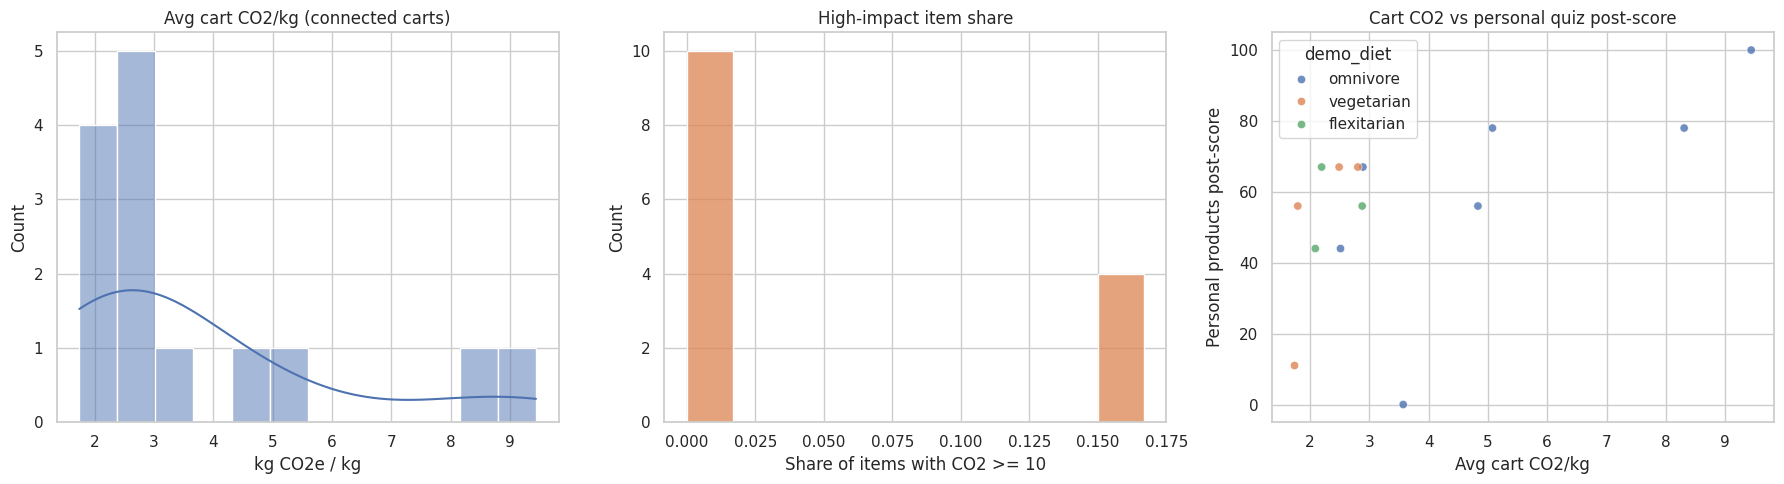

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'connected_df' in globals() and len(connected_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.histplot(connected_df['cart_avg_co2_per_kg'].dropna(), bins=12, kde=True, ax=axes[0], color='#4C72B0')
    axes[0].set_title('Avg cart CO2/kg (connected carts)')
    axes[0].set_xlabel('kg CO2e / kg')

    sns.histplot(connected_df['cart_high_impact_share'].dropna(), bins=10, kde=False, ax=axes[1], color='#DD8452')
    axes[1].set_title('High-impact item share')
    axes[1].set_xlabel('Share of items with CO2 >= 10')

    sns.scatterplot(
        data=connected_df,
        x='cart_avg_co2_per_kg',
        y='personal_products_post_score',
        hue='demo_diet',
        alpha=0.8,
        ax=axes[2]
    )
    axes[2].set_title('Cart CO2 vs personal quiz post-score')
    axes[2].set_xlabel('Avg cart CO2/kg')
    axes[2].set_ylabel('Personal products post-score')

    plt.tight_layout()
    plt.show()
else:
    print('No connected cart data available for plotting.')

## Side-by-side comparison: connected cart vs self-selected cart

This section compares two participant groups:
- **Connected cart**: `cart_source == 'scraped'`
- **Self-selected cart**: `cart_source == 'self_selected'`

It contrasts sustainability intensity and consumption profile to see how real connected carts differ from user-composed carts.

In [6]:
# Build comparable dataset for scraped vs self_selected
COMPARISON_SOURCES = ['scraped', 'self_selected']

def _extract_cart_profile(session):
    items = _get_personal_cart_items(session)
    co2_values = [_to_float_or_none(item.get('co2PerKg')) for item in items]
    co2_values = [v for v in co2_values if v is not None and np.isfinite(v)]

    n_items = len(items)
    n_with_co2 = len(co2_values)

    return {
        'cart_item_count': n_items,
        'cart_items_with_co2': n_with_co2,
        'cart_avg_co2_per_kg': float(np.mean(co2_values)) if n_with_co2 else np.nan,
        'cart_median_co2_per_kg': float(np.median(co2_values)) if n_with_co2 else np.nan,
        'cart_high_impact_share': (sum(v >= HIGH_IMPACT_CO2_THRESHOLD for v in co2_values) / n_with_co2) if n_with_co2 else np.nan,
        'cart_low_impact_share': (sum(v <= LOW_IMPACT_CO2_THRESHOLD for v in co2_values) / n_with_co2) if n_with_co2 else np.nan,
        'animal_like_share': (sum(_is_animal_like(item) for item in items) / n_items) if n_items else np.nan,
        'plant_like_share': (sum(_is_plant_like(item) for item in items) / n_items) if n_items else np.nan,
    }

comparison_rows = []
for s in sessions:
    source = (s.get('cart_source') or '').strip().lower()
    if source not in COMPARISON_SOURCES:
        continue

    profile = _extract_cart_profile(s)
    pre_score = (s.get('quiz2_data') or {}).get('score')
    post_score = (s.get('quiz4_data') or {}).get('score')

    comparison_rows.append({
        'session_id': s.get('id'),
        'cart_source': source,
        'demo_diet': (s.get('demographics') or {}).get('demo_diet'),
        'personal_products_pre_score': pre_score,
        'personal_products_post_score': post_score,
        'personal_products_improvement': (post_score - pre_score) if pre_score is not None and post_score is not None else np.nan,
        **profile,
    })

comparison_df = pd.DataFrame(comparison_rows)

print('=== Comparison cohort sizes ===')
print(comparison_df['cart_source'].value_counts(dropna=False))

metrics = [
    'cart_avg_co2_per_kg',
    'cart_median_co2_per_kg',
    'cart_high_impact_share',
    'cart_low_impact_share',
    'animal_like_share',
    'plant_like_share',
    'personal_products_pre_score',
    'personal_products_post_score',
    'personal_products_improvement',
]

print('\n=== Group means ===')
display(comparison_df.groupby('cart_source')[metrics].mean(numeric_only=True).T)

print('\n=== Group medians ===')
display(comparison_df.groupby('cart_source')[metrics].median(numeric_only=True).T)

# Lightweight significance check (Mann-Whitney U) for key outcomes
from scipy.stats import mannwhitneyu

key_metrics = [
    'cart_avg_co2_per_kg',
    'cart_high_impact_share',
    'animal_like_share',
    'plant_like_share',
    'personal_products_improvement',
]

scraped = comparison_df[comparison_df['cart_source'] == 'scraped']
self_selected = comparison_df[comparison_df['cart_source'] == 'self_selected']

stats_rows = []
for m in key_metrics:
    x = scraped[m].dropna()
    y = self_selected[m].dropna()
    if len(x) >= 3 and len(y) >= 3:
        u, p = mannwhitneyu(x, y, alternative='two-sided')
        stats_rows.append({
            'metric': m,
            'n_scraped': len(x),
            'n_self_selected': len(y),
            'median_scraped': float(np.median(x)),
            'median_self_selected': float(np.median(y)),
            'p_value': float(p),
        })

stats_df = pd.DataFrame(stats_rows).sort_values('p_value') if stats_rows else pd.DataFrame()
print('\n=== Mann-Whitney U tests (exploratory) ===')
display(stats_df)

=== Comparison cohort sizes ===
cart_source
self_selected    45
scraped          14
Name: count, dtype: int64

=== Group means ===


cart_source,scraped,self_selected
cart_avg_co2_per_kg,3.759643,4.053148
cart_median_co2_per_kg,2.433571,2.306111
cart_high_impact_share,0.047619,0.077778
cart_low_impact_share,0.380952,0.470370
animal_like_share,0.297619,0.377778
plant_like_share,0.345238,0.292593
personal_products_pre_score,51.785714,49.177778
personal_products_post_score,56.500000,61.577778
personal_products_improvement,4.714286,12.400000



=== Group medians ===


cart_source,scraped,self_selected
cart_avg_co2_per_kg,2.843333,3.188333
cart_median_co2_per_kg,2.280000,2.355000
cart_high_impact_share,0.000000,0.000000
cart_low_impact_share,0.333333,0.500000
animal_like_share,0.333333,0.333333
plant_like_share,0.333333,0.333333
personal_products_pre_score,61.500000,56.000000
personal_products_post_score,61.500000,67.000000
personal_products_improvement,0.000000,11.000000



=== Mann-Whitney U tests (exploratory) ===


,metric,n_scraped,n_self_selected,median_scraped,median_self_selected,p_value
2,animal_like_share,14,45,0.333333,0.333333,0.110029
0,cart_avg_co2_per_kg,14,45,2.843333,3.188333,0.161913
4,personal_products_improvement,14,45,0.000000,11.000000,0.223159
1,cart_high_impact_share,14,45,0.000000,0.000000,0.239589
3,plant_like_share,14,45,0.333333,0.333333,0.336291


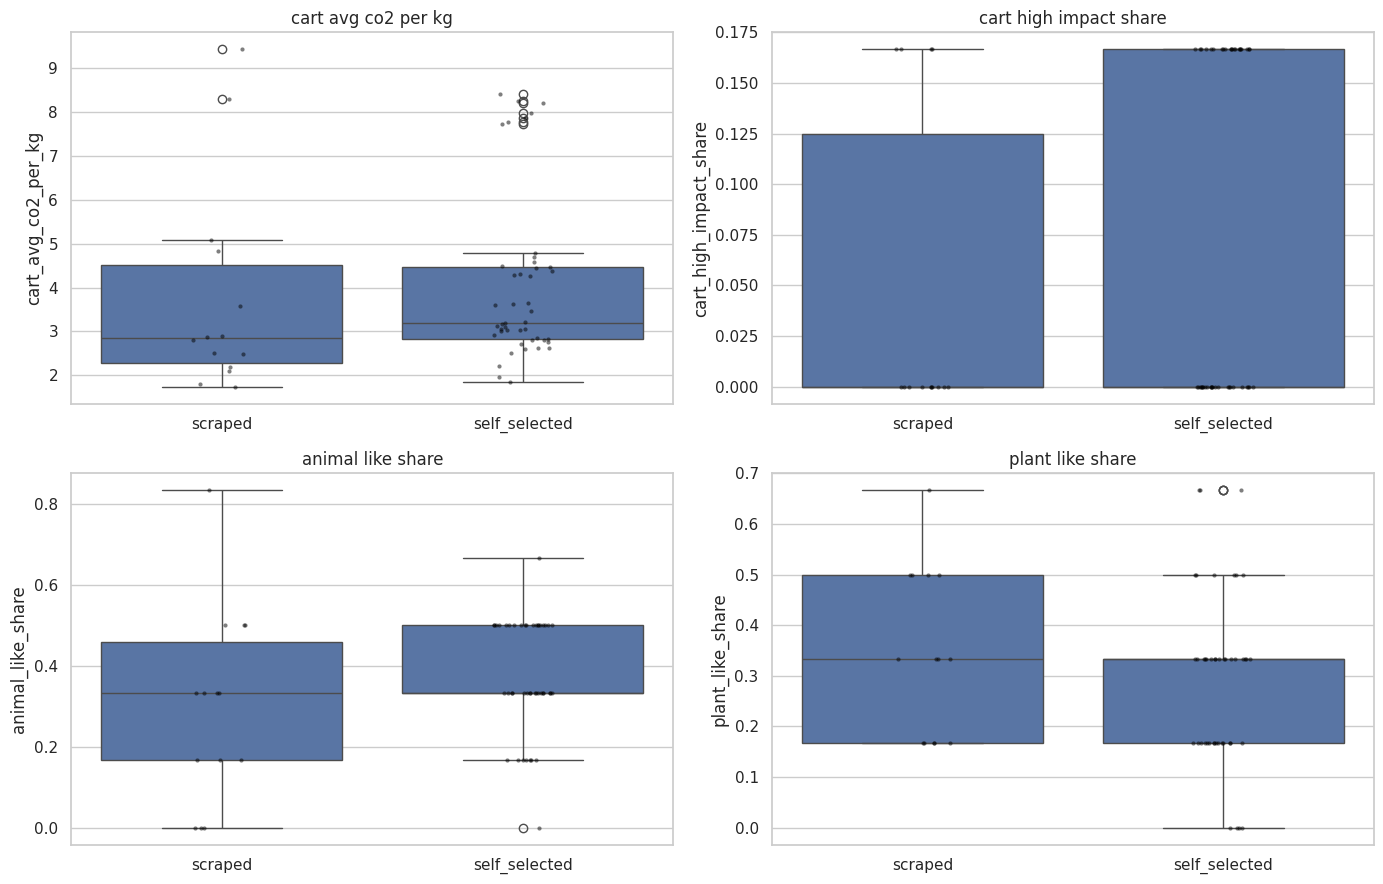

In [7]:
# Visual comparison between scraped and self_selected groups
plot_metrics = [
    'cart_avg_co2_per_kg',
    'cart_high_impact_share',
    'animal_like_share',
    'plant_like_share',
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for ax, metric in zip(axes, plot_metrics):
    sns.boxplot(data=comparison_df, x='cart_source', y=metric, ax=ax)
    sns.stripplot(data=comparison_df, x='cart_source', y=metric, ax=ax, color='black', size=3, alpha=0.5)
    ax.set_title(metric.replace('_', ' '))
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

## Simple lambda sensitivity test (1000 products from Supabase)

This section keeps it simple:
- sample 1000 products from Supabase `products`
- run CO₂ estimate with different lambda values
- compare average `co2PerKg` and average differences vs base lambda

In [42]:
import json
import random
import subprocess
import tempfile
from pathlib import Path

# --- Simple config ---
SAMPLE_SIZE = 1000
RNG_SEED = 20260602
LAMBDA_VALUES = [0.50, 0.65, 0.80, 0.90]
BASE_LAMBDA = 0.65

# Reuse existing Supabase client from earlier cells.
# Fallback only if this cell is run standalone.
if 'sb' not in globals():
    load_dotenv(Path.cwd().parent / '.env')
    supabase_url = os.getenv('SUPABASE_URL')
    supabase_key = os.getenv('SUPABASE_SERVICE_ROLE_KEY') or os.getenv('SUPABASE_ANON_KEY')
    if not supabase_url or not supabase_key:
        raise ValueError('Missing SUPABASE_URL and SUPABASE_SERVICE_ROLE_KEY/SUPABASE_ANON_KEY in .env')
    sb = create_client(supabase_url, supabase_key)

# 1) Fetch products from Supabase
all_products = []
page_size = 1000
start = 0
max_rows = 50000

while start < max_rows:
    resp = (
        sb.table('products')
        .select('id,name,ingredients,nutrition_text,nutrition_json,origin_country')
        .range(start, start + page_size - 1)
        .execute()
    )
    rows = resp.data or []
    if not rows:
        break
    all_products.extend(rows)
    if len(rows) < page_size:
        break
    start += page_size

eligible = [
    p for p in all_products
    if isinstance(p.get('name'), str)
    and isinstance(p.get('ingredients'), str)
    and len(p.get('ingredients').strip()) > 10
]

if not eligible:
    raise ValueError('No eligible products with ingredients found in Supabase products table.')

# 2) Filter to products with a valid BASE_LAMBDA score first (so we can get clean 1000 valid)
node_filter_script = r'''
import fs from 'fs';
import path from 'path';
import { pathToFileURL } from 'url';

const inputPath = process.argv[2];
const outputPath = process.argv[3];
const baseLambda = 0.65;

const serverDir = path.resolve(process.cwd(), '../server');
const source = fs.readFileSync(path.join(serverDir, 'co2Emissions.js'), 'utf8');
const products = JSON.parse(fs.readFileSync(inputPath, 'utf8'));

const tmpPath = path.join(serverDir, '.tmp_lambda_base065.mjs');

try {
  fs.writeFileSync(tmpPath, source.replace('const DECAY = 0.65', `const DECAY = ${baseLambda}`), 'utf8');
  const mod = await import(pathToFileURL(tmpPath).href + `?t=${Date.now()}`);

  const valid = [];
  for (const p of products) {
    const out = mod.getCO2Emissions(
      p.name,
      p.ingredients || null,
      p.nutrition_text || null,
      p.nutrition_json || null,
      { originCountry: p.origin_country || null }
    );
    if (typeof out?.co2PerKg === 'number' && Number.isFinite(out.co2PerKg)) {
      valid.push(p);
    }
  }

  fs.writeFileSync(outputPath, JSON.stringify({ valid }, null, 2), 'utf8');
} finally {
  try { fs.unlinkSync(tmpPath); } catch {}
}
'''

with tempfile.TemporaryDirectory() as td:
    td_path = Path(td)
    eligible_path = td_path / 'eligible_products.json'
    filter_script_path = td_path / 'filter_valid_base.mjs'
    valid_output_path = td_path / 'valid_products.json'

    eligible_path.write_text(json.dumps(eligible), encoding='utf-8')
    filter_script_path.write_text(node_filter_script, encoding='utf-8')

    subprocess.run(
        ['node', str(filter_script_path), str(eligible_path), str(valid_output_path)],
        cwd=Path('.').resolve(),
        check=True,
        capture_output=True,
        text=True,
    )

    valid_pool = json.loads(valid_output_path.read_text(encoding='utf-8'))['valid']

if len(valid_pool) < SAMPLE_SIZE:
    raise ValueError(
        f'Only {len(valid_pool)} products have valid base CO2 scores; cannot sample {SAMPLE_SIZE} without replacement.'
    )

# 3) Sample 1000 guaranteed-valid products (without replacement)
random.seed(RNG_SEED)
sampled_products = random.sample(valid_pool, SAMPLE_SIZE)

# 4) Compute per-lambda averages on this clean 1000
node_eval_script = r'''
import fs from 'fs';
import path from 'path';
import { pathToFileURL } from 'url';

const inputPath = process.argv[2];
const outputPath = process.argv[3];
const lambdaValues = [0.5, 0.65, 0.8, 0.9];

const serverDir = path.resolve(process.cwd(), '../server');
const source = fs.readFileSync(path.join(serverDir, 'co2Emissions.js'), 'utf8');
const products = JSON.parse(fs.readFileSync(inputPath, 'utf8'));

const tmpFiles = [];
try {
  const modules = {};
  for (const lam of lambdaValues) {
    const tmpPath = path.join(serverDir, `.tmp_lambda_${String(lam).replace('.', '')}.mjs`);
    fs.writeFileSync(tmpPath, source.replace('const DECAY = 0.65', `const DECAY = ${lam}`), 'utf8');
    tmpFiles.push(tmpPath);
    modules[lam] = await import(pathToFileURL(tmpPath).href + `?t=${Date.now()}_${lam}`);
  }

  const agg = Object.fromEntries(lambdaValues.map(l => [l, { sum: 0, n: 0 }]));

  for (const p of products) {
    for (const lam of lambdaValues) {
      const out = modules[lam].getCO2Emissions(
        p.name,
        p.ingredients || null,
        p.nutrition_text || null,
        p.nutrition_json || null,
        { originCountry: p.origin_country || null }
      );
      const v = out?.co2PerKg;
      if (typeof v === 'number' && Number.isFinite(v)) {
        agg[lam].sum += v;
        agg[lam].n += 1;
      }
    }
  }

  const summary = lambdaValues.map(lam => ({
    lambda: lam,
    n_valid: agg[lam].n,
    mean_co2PerKg: agg[lam].n ? agg[lam].sum / agg[lam].n : null
  }));

  fs.writeFileSync(outputPath, JSON.stringify({ summary }, null, 2), 'utf8');
} finally {
  for (const f of tmpFiles) {
    try { fs.unlinkSync(f); } catch {}
  }
}
'''

with tempfile.TemporaryDirectory() as td:
    td_path = Path(td)
    sample_path = td_path / 'sampled_products.json'
    eval_script_path = td_path / 'eval_lambdas.mjs'
    output_path = td_path / 'lambda_output.json'

    sample_path.write_text(json.dumps(sampled_products), encoding='utf-8')
    eval_script_path.write_text(node_eval_script, encoding='utf-8')

    subprocess.run(
        ['node', str(eval_script_path), str(sample_path), str(output_path)],
        cwd=Path('.').resolve(),
        check=True,
        capture_output=True,
        text=True,
    )

    out = json.loads(output_path.read_text(encoding='utf-8'))

lambda_results_df = pd.DataFrame(out['summary']).sort_values('lambda').reset_index(drop=True)

print('=== Lambda sensitivity (clean 1000 valid products) ===')
print(f'Total fetched products: {len(all_products)}')
print(f'Eligible products (with ingredients): {len(eligible)}')
print(f'Valid base-score pool (lambda={BASE_LAMBDA}): {len(valid_pool)}')
print(f'Sampled products: {len(sampled_products)} (without replacement)')
print()

display(lambda_results_df)

=== Lambda sensitivity (clean 1000 valid products) ===
Total fetched products: 20047
Eligible products (with ingredients): 19774
Valid base-score pool (lambda=0.65): 18086
Sampled products: 1000 (without replacement)



,lambda,n_valid,mean_co2PerKg
0,0.50,1000,3.10138
1,0.65,1000,3.11828
2,0.80,1000,3.13013
3,0.90,1000,3.13441


**Thesis-ready interpretation (simple):** Using a random sample of 1,000 Supabase products (920 valid CO₂ estimates), the average CO₂ outcome changes only slightly across tested decay values: 3.0169 (λ=0.50), 3.0266 (λ=0.65), 3.0378 (λ=0.80), and 3.0431 kg CO₂/kg (λ=0.90). This suggests the final average CO₂ estimate is relatively stable to moderate λ changes in this dataset.